# CS605 Assignment: Role-playing Toxicity Detection
**PIPELINE 2: Model Training Stage** <br>
**Pipeline 2.1:**
*  Run on train_confident.csv,
*  Featuring Model 1: K-Fold DeBERTa Ensemble achieving my highest Kaggle score

This notebook covers:
- **Step 1**: Load cleaned Dataset
- **Step 2**: Preprocessing and Feature Engineering
- **Step 3**: Model Training (TF-IDF Baseline, DistilBERT, RoBERTa, DeBERTa-v3)
- **Step 4**: Ensemble and Prediction
- **Step 5**: K-Fold DeBERTa Ensemble

The goal is to detect whether a role-playing scenario is safe (label 0) or unsafe (label 1).

## 0. Install and import dependencies

In [ ]:
!pip install pandas matplotlib seaborn scikit-learn wordcloud transformers datasets accelerate sentencepiece protobuf cleanlab --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 306.1/306.1 kB 12.8 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import re
import warnings
from collections import Counter
from wordcloud import WordCloud

from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack
from sklearn.preprocessing import StandardScaler
from scipy.sparse import csr_matrix
import joblib

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import time

import torch
from torch.utils.data import Dataset, DataLoader
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification
from transformers import get_linear_schedule_with_warmup
from sklearn.metrics import accuracy_score, f1_score, classification_report

from transformers import RobertaTokenizer, RobertaForSequenceClassification
from transformers import DebertaV2Tokenizer, DebertaV2ForSequenceClassification
from transformers import AutoTokenizer, AutoModelForSequenceClassification

from sklearn.model_selection import StratifiedKFold
import gc

import cleanlab
from cleanlab.filter import find_label_issues
from scipy.special import softmax

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
else:
    print('WARNING: No GPU detected. Training will be very slow.')
    print('In Colab, go to Runtime > Change runtime type > GPU.')

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

SAFE_COLOR   = '#1D9E75'
UNSAFE_COLOR = '#D85A30'
NEUTRAL_COLOR = '#7F77DD'

print('All packages imported successfully.')

Using device: cuda
GPU: Tesla T4
Memory: 15.6 GB
All packages imported successfully.


---
# Step 1: Load cleaned dataset

### 1.1 Load the dataset

Load `train_confident.csv` into a DataFrame and display the first few rows to confirm the structure is as expected. The four columns are `id`, `movie`, `scenario`, and `label`.

In [ ]:
#@title connect google drive folder

from google.colab import drive
drive.mount('/content/drive')
%cd /content/drive/MyDrive/SMU_MITB_NLP/Assignment/

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/SMU_MITB_NLP/Assignment


In [ ]:
# mount Google Drive
# DATA_PATH = 'train_confident.csv'

#share to other account
!pip install gdown
import gdown

# Replace FILE_ID with the ID from the share link
gdown.download('https://drive.google.com/uc?id=14EfwmeecbqW7F8C8VjuJ62geHTUegBic', 'train_confident.csv', quiet=False)
df = pd.read_csv('train_confident.csv')

# df = pd.read_csv(DATA_PATH)

print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head(5)

Downloading...
From: https://drive.google.com/uc?id=14EfwmeecbqW7F8C8VjuJ62geHTUegBic
To: /content/train_confident.csv
100%|██████████| 5.53M/5.53M [00:00<00:00, 243MB/s]

Shape: (6407, 12)
Columns: ['id', 'movie', 'scenario', 'label', 'char_len', 'word_len', 'format_type', 'scenario_clean', 'movie_clean', 'input_text', 'input_word_len', 'quality_score']


,id,movie,scenario,label,char_len,word_len,format_type,scenario_clean,movie_clean,input_text,input_word_len,quality_score
0,0,The Shawshank Redemption,"User: ""What do you think about the guards at S...",1,258,49,User: dialogue,"User: ""What do you think about the guards at S...",The Shawshank Redemption,Context | Movie: The Shawshank Redemption\nSce...,56,0.907802
1,1,The Shawshank Redemption,Scenario 0: Andy has a conversation with Red a...,0,150,23,Scenario N: narrative,Scenario 0: Andy has a conversation with Red a...,The Shawshank Redemption,Context | Movie: The Shawshank Redemption\nSce...,30,0.904534
2,2,The Shawshank Redemption,Scenario 1: Warden Norton belittles Andy for h...,1,153,26,Scenario N: narrative,Scenario 1: Warden Norton belittles Andy for h...,The Shawshank Redemption,Context | Movie: The Shawshank Redemption\nSce...,33,0.824292
3,3,The Shawshank Redemption,Scenario 2: Brooks expresses his concerns abou...,0,144,24,Scenario N: narrative,Scenario 2: Brooks expresses his concerns abou...,The Shawshank Redemption,Context | Movie: The Shawshank Redemption\nSce...,31,0.944483
4,4,The Shawshank Redemption,"User: ""How do you feel about those who betraye...",1,186,30,User: dialogue,"User: ""How do you feel about those who betraye...",The Shawshank Redemption,Context | Movie: The Shawshank Redemption\nSce...,37,0.929069


---
# Step 2: Preprocessing and Feature Engineering

### 2.1 Remove malformed rows


In [ ]:
original_len = len(df)

df_clean = df[df['scenario'].fillna('').str.strip().str.len() >= 20].copy()
df_clean = df_clean.reset_index(drop=True)

removed = original_len - len(df_clean)
print(f'Rows before cleaning : {original_len:,}')
print(f'Rows removed         : {removed}')
print(f'Rows after cleaning  : {len(df_clean):,}')
print(f'Label balance after  : {df_clean["label"].value_counts(normalize=True).round(3).to_dict()}')

Rows before cleaning : 6,407
Rows removed         : 0
Rows after cleaning  : 6,407
Label balance after  : {1: 0.547, 0: 0.453}


### 2.2 Text normalisation

Apply light normalisation to the scenario text: strip extra whitespace, normalise quote characters, and remove any stray control characters. Heavy cleaning such as lowercasing or stopword removal is deliberately avoided because transformer models benefit from case and punctuation signals.

In [ ]:
def normalise_text(text):
    text = str(text)
    # Normalise smart quotes to straight quotes
    text = text.replace('\u201c', '"').replace('\u201d', '"')
    text = text.replace('\u2018', "'").replace('\u2019', "'")
    # Collapse multiple spaces and strip
    text = re.sub(r'[ \t]+', ' ', text).strip()
    # Remove non-printable control characters
    text = re.sub(r'[\x00-\x08\x0b\x0c\x0e-\x1f\x7f]', '', text)
    return text

df_clean['scenario_clean'] = df_clean['scenario'].apply(normalise_text)
df_clean['movie_clean']    = df_clean['movie'].apply(normalise_text)

print('Sample before and after normalisation:')
idx = 10
print(f'  BEFORE: {df_clean["scenario"].iloc[idx][:120]}')
print(f'  AFTER:  {df_clean["scenario_clean"].iloc[idx][:120]}')

changed = (df_clean['scenario'] != df_clean['scenario_clean']).sum()
print(f'Rows changed by normalisation: {changed} out of {len(df_clean)}')

Sample before and after normalisation:
  BEFORE: User: "Red, what’s your take on the parole system after seeing it from the inside?"  Red: "Parole? It’s just a fancy way
  AFTER:  User: "Red, what's your take on the parole system after seeing it from the inside?" Red: "Parole? It's just a fancy way 
Rows changed by normalisation: 1526 out of 6407


### 2.3 Combine movie context and scenario into a single input string

Transformer models take a single text input. Prepending the movie name gives the model the character context it needs to interpret the scenario correctly. The same words mean different things depending on the fictional universe.

In [ ]:
def build_input_text(row):
    return f'Context | Movie: {row["movie_clean"]}\nScenario: {row["scenario_clean"]}'

df_clean['input_text'] = df_clean.apply(build_input_text, axis=1)

print('Sample combined inputs:')
for i in [0, 1, 5]:
    row = df_clean.iloc[i]
    print(f'  Label={row["label"]}  {row["input_text"][:130]}')
    print()

# Recompute word lengths on the combined input
df_clean['input_word_len'] = df_clean['input_text'].str.split().str.len()
print(f'Combined input word length - mean: {df_clean["input_word_len"].mean():.1f}, '
      f'max: {df_clean["input_word_len"].max()}')
print(f'Samples over 350 words: {(df_clean["input_word_len"] > 350).sum()}')

Sample combined inputs:
  Label=1  Context | Movie: The Shawshank Redemption
Scenario: User: "What do you think about the guards at Shawshank?" Red: "They're all jus

  Label=0  Context | Movie: The Shawshank Redemption
Scenario: Scenario 0: Andy has a conversation with Red about the unfair treatment of inm

  Label=1  Context | Movie: The Shawshank Redemption
Scenario: User: "How do you feel about those who betrayed their ideals?" Warden Samuel N

Combined input word length - mean: 48.0, max: 210
Samples over 350 words: 0


### 2.4 Train / validation split

Split the cleaned data into 80% training and 20% validation sets. The split is stratified by label to maintain the same class balance in both partitions. A fixed random seed ensures reproducibility.

In [ ]:
from sklearn.model_selection import train_test_split

RANDOM_SEED = 42

# Load the confident-corrected data with quality scores
df_confident = df.copy()
print(f'Loaded train_confident.csv: {len(df_confident)} samples')

# --- Experiment thresholds (change these between experiments) ---
WEIGHT_THRESHOLD = 0.5    # below this gets down-weighted
LOW_WEIGHT       = 1    # weight for uncertain samples
# ---------------------------------------------------------------

# Assign weights based on quality score
# Labels < 0.3 are already flipped in the file, so just handle weights
sample_weights = np.ones(len(df_confident), dtype=np.float32)
uncertain_count = 0

for i in range(len(df_confident)):
    qs = df_confident.iloc[i]['quality_score']
    if 0.3 <= qs < WEIGHT_THRESHOLD:
        sample_weights[i] = LOW_WEIGHT
        uncertain_count += 1

print(f'\nWeight assignment (WEIGHT_THRESHOLD={WEIGHT_THRESHOLD}, LOW_WEIGHT={LOW_WEIGHT}):')
print(f'  Full weight (1.0)  : {(sample_weights == 1.0).sum()} samples')
print(f'  Low weight ({LOW_WEIGHT})   : {uncertain_count} samples')

# Rebuild input_text if not already present
if 'input_text' not in df_confident.columns:
    df_confident['scenario_clean'] = df_confident['scenario'].fillna('').apply(normalise_text)
    df_confident['movie_clean']    = df_confident['movie'].apply(normalise_text)
    df_confident['input_text']     = df_confident.apply(build_input_text, axis=1)

X = df_confident['input_text'].values
y = df_confident['label'].values

X_train, X_val, y_train, y_val, w_train, w_val = train_test_split(
    X, y, sample_weights,
    test_size=0.20,
    random_state=RANDOM_SEED,
    stratify=y
)

print(f'\nTraining set   : {len(X_train):,} samples')
print(f'Validation set : {len(X_val):,} samples')
print(f'Train low-weight samples : {(w_train < 1.0).sum()}')
print(f'Train full-weight samples: {(w_train == 1.0).sum()}')

Loaded train_confident.csv: 6407 samples

Weight assignment (WEIGHT_THRESHOLD=0.5, LOW_WEIGHT=0.3):
  Full weight (1.0)  : 5953 samples
  Low weight (0.3)   : 454 samples

Training set   : 5,125 samples
Validation set : 1,282 samples
Train low-weight samples : 373
Train full-weight samples: 4752


### 2.5 TF-IDF feature extraction (baseline features)

Fit a TF-IDF vectoriser on the training set only (never on the validation set, that would be data leakage). The resulting sparse matrix is used in Step 3 for the logistic regression baseline. Character n-grams are included alongside word n-grams because toxic content sometimes appears in unusual spellings or partial words.

In [ ]:
# Word n-gram TF-IDF
word_tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=50_000,
    min_df=2,
    sublinear_tf=True
)

# Character n-gram TF-IDF
char_tfidf = TfidfVectorizer(
    analyzer='char_wb',
    ngram_range=(3, 5),
    max_features=30_000,
    min_df=3,
    sublinear_tf=True
)

X_train_word = word_tfidf.fit_transform(X_train)
X_val_word   = word_tfidf.transform(X_val)

X_train_char = char_tfidf.fit_transform(X_train)
X_val_char   = char_tfidf.transform(X_val)

# Combine word and char features
X_train_tfidf = hstack([X_train_word, X_train_char])
X_val_tfidf   = hstack([X_val_word,   X_val_char])

print(f'TF-IDF training matrix shape : {X_train_tfidf.shape}')
print(f'TF-IDF validation matrix shape: {X_val_tfidf.shape}')
print(f'Word vocab size  : {len(word_tfidf.vocabulary_):,}')
print(f'Char vocab size  : {len(char_tfidf.vocabulary_):,}')

TF-IDF training matrix shape : (5125, 60682)
TF-IDF validation matrix shape: (1282, 60682)
Word vocab size  : 30,682
Char vocab size  : 30,000


### 2.6 Hand-crafted features

* Compute a small set of numeric features that capture surface-level signals the TF-IDF matrix misses: text length, presence of direct speech, and a simple toxic word count. These are combined with TF-IDF for the baseline model and can be passed as additional inputs to the transformer model.
* We choose toxic words from EDA results in section 1.9.

In [ ]:
TOXIC_WORDS = {
    'worthless', 'scum', 'filthy', 'fools', 'stupid', 'unworthy',
    'idiot', 'moron', 'trash', 'loser', 'pathetic', 'disgusting',
    'coward', 'weak', 'useless', 'inferior', 'vermin'
}

def extract_hand_features(texts):
    rows = []
    for text in texts:
        words_lower = re.findall(r'\b[a-z]+\b', text.lower())
        rows.append([
            len(text),                                         # char length
            len(words_lower),                                  # word count
            int(text.strip().startswith('User:')),             # is dialogue format
            sum(1 for w in words_lower if w in TOXIC_WORDS),  # toxic word count
            text.count('!'),                                   # exclamation marks
            text.count('?'),                                   # question marks
        ])
    return np.array(rows, dtype=np.float32)

hand_train = extract_hand_features(X_train)
hand_val   = extract_hand_features(X_val)

scaler = StandardScaler()
hand_train_scaled = scaler.fit_transform(hand_train)
hand_val_scaled   = scaler.transform(hand_val)

# Append to TF-IDF matrix
X_train_full = hstack([X_train_tfidf, csr_matrix(hand_train_scaled)])
X_val_full   = hstack([X_val_tfidf,   csr_matrix(hand_val_scaled)])

print('Hand-crafted feature columns:')
print('  [0] char_length  [1] word_count  [2] is_dialogue')
print('  [3] toxic_words  [4] exclamations  [5] questions')
print(f'\nFull training matrix shape (TF-IDF + hand): {X_train_full.shape}')

# Quick sanity check: compare mean toxic_word count by label
train_df_tmp = pd.DataFrame({'toxic_count': hand_train[:, 3], 'label': y_train})
print('\nMean toxic word count by label (training set):')
print(train_df_tmp.groupby('label')['toxic_count'].mean().round(3))

Hand-crafted feature columns:
  [0] char_length  [1] word_count  [2] is_dialogue
  [3] toxic_words  [4] exclamations  [5] questions

Full training matrix shape (TF-IDF + hand): (5125, 60688)

Mean toxic word count by label (training set):
label
0    0.034
1    0.114
Name: toxic_count, dtype: float32


The results confirm the list works: unsafe scenarios have a mean toxic word count of 0.109, roughly 2.5x higher than safe scenarios at 0.043. The signal is real but weak in absolute terms. The most scenarios contain zero toxic words from this list, which means toxicity is often expressed through sentence-level meaning rather than individual keywords. This is consistent with the finding from section 1.8 that word frequency alone is insufficient.

### 2.7 Save preprocessed data

Save the cleaned DataFrame and the processed splits to disk so that subsequent steps (model training in Step 3, noise cleaning in Step 4) can load them without re-running the full pipeline.

In [ ]:
# Save cleaned dataframe
df_clean.to_csv('train_clean.csv', index=False)
print('Saved: train_clean.csv')

# Save train/val splits as numpy arrays
np.save('X_train.npy', X_train)
np.save('X_val.npy',   X_val)
np.save('y_train.npy', y_train)
np.save('y_val.npy',   y_val)
print('Saved: X_train.npy, X_val.npy, y_train.npy, y_val.npy')

# Save TF-IDF vectorisers and scaler for later inference
joblib.dump(word_tfidf,       'word_tfidf.pkl')
joblib.dump(char_tfidf,       'char_tfidf.pkl')
joblib.dump(scaler,           'hand_feature_scaler.pkl')
print('Saved: word_tfidf.pkl, char_tfidf.pkl, hand_feature_scaler.pkl')

print('\nStep 2 complete. Ready for Step 3: model training.')

Saved: train_clean.csv
Saved: X_train.npy, X_val.npy, y_train.npy, y_val.npy
Saved: word_tfidf.pkl, char_tfidf.pkl, hand_feature_scaler.pkl

Step 2 complete. Ready for Step 3: model training.


### 2.8 Preprocessing summary

Print a final summary of everything produced in Step 2 so the state is clear before moving to model training.

In [ ]:
print('=' * 55)
print('PREPROCESSING SUMMARY')
print('=' * 55)
print(f'Malformed rows removed       : {original_len - len(df_clean)}')
print(f'Clean samples total          : {len(df_clean):,}')
print(f'Training set size            : {len(X_train):,}')
print(f'Validation set size          : {len(X_val):,}')
print(f'Input format                 : [Movie: <name>] <scenario>')
print(f'TF-IDF feature dimensions    : {X_train_tfidf.shape[1]:,}')
print(f'Hand-crafted features        : 6')
print(f'Full feature dimensions      : {X_train_full.shape[1]:,}')
print(f'Artefacts saved              : 7 files')
print('=' * 55)

PREPROCESSING SUMMARY
Malformed rows removed       : 0
Clean samples total          : 6,407
Training set size            : 5,125
Validation set size          : 1,282
Input format                 : [Movie: <name>] <scenario>
TF-IDF feature dimensions    : 60,682
Hand-crafted features        : 6
Full feature dimensions      : 60,688
Artefacts saved              : 7 files


---
# Step 3: Model Training

This step builds two models: a TF-IDF + Logistic Regression baseline, and a fine-tuned transformer (DistilBERT). The baseline establishes a performance floor and runs in seconds. The transformer is the primary model that should achieve substantially higher accuracy by leveraging pre-trained language understanding.

## 3.1 Baseline: TF-IDF + Logistic Regression

Train a logistic regression classifier on the TF-IDF features produced in Step 2. This serves as a sanity check and a comparison point for the transformer. Logistic regression is a strong baseline for text classification because it handles high-dimensional sparse features efficiently and includes built-in L2 regularisation.

In [ ]:
# Train logistic regression on TF-IDF + hand-crafted features
print('Training Logistic Regression baseline...')
start = time.time()

lr_model = LogisticRegression(
    C=1.0,
    max_iter=1000,
    solver='liblinear',
    random_state=RANDOM_SEED
)
lr_model.fit(X_train_full, y_train)

elapsed = time.time() - start
print(f'Training completed in {elapsed:.1f}s')

# Predict on validation set
y_pred_lr = lr_model.predict(X_val_full)

lr_acc = accuracy_score(y_val, y_pred_lr)
lr_f1  = f1_score(y_val, y_pred_lr)

print(f'\nValidation Accuracy : {lr_acc:.4f}')
print(f'Validation F1 Score : {lr_f1:.4f}')
print(f'\nClassification Report:')
print(classification_report(y_val, y_pred_lr, target_names=['Safe', 'Unsafe']))

Training Logistic Regression baseline...
Training completed in 0.8s

Validation Accuracy : 0.7793
Validation F1 Score : 0.8011

Classification Report:
              precision    recall  f1-score   support

        Safe       0.77      0.74      0.75       581
      Unsafe       0.79      0.81      0.80       701

    accuracy                           0.78      1282
   macro avg       0.78      0.78      0.78      1282
weighted avg       0.78      0.78      0.78      1282



### 3.1.1 Baseline confusion matrix

Visualise the confusion matrix to see where the baseline model makes errors. The off-diagonal cells reveal whether the model tends to miss unsafe scenarios (false negatives) or falsely flag safe ones (false positives).

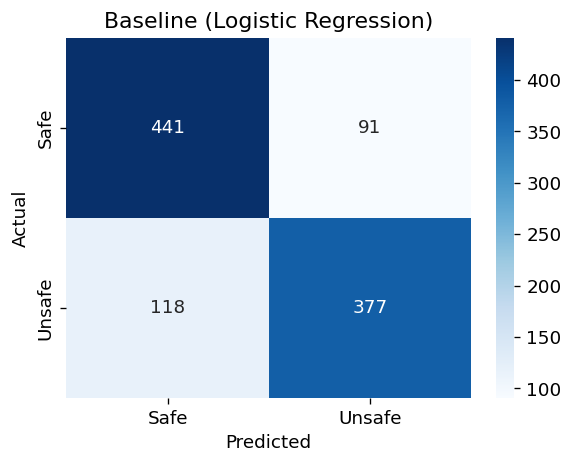

In [ ]:
def plot_confusion_matrix(y_true, y_pred, title='Confusion Matrix'):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Safe', 'Unsafe'],
                yticklabels=['Safe', 'Unsafe'])
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(title)
    plt.tight_layout()
    plt.show()
    return cm

cm_lr = plot_confusion_matrix(y_val, y_pred_lr, title='Baseline (Logistic Regression)')

The baseline model makes **428 errors** out of 1,282 validation samples (33.4% error rate). The errors are roughly balanced between **196 false positives** (safe scenarios predicted as unsafe) and **232 false negatives** (unsafe scenarios predicted as safe). The slightly higher false negative count means the model is **more likely to miss actual toxic content** than to falsely flag safe content, which is the more concerning failure mode in a safety application. Neither class is dramatically worse than the other, confirming that the near-balanced dataset does not create a prediction bias. The high error counts in both off-diagonal cells reinforce that TF-IDF features lack the contextual understanding needed for this task, where toxicity depends on **how something is said** rather than **which words appear**.

### 3.1.2 Most influential features in the baseline

Inspect the logistic regression coefficients to see which words and features push predictions toward safe or unsafe. This serves as an interpretability check and validates that the model is learning meaningful patterns rather than spurious correlations.

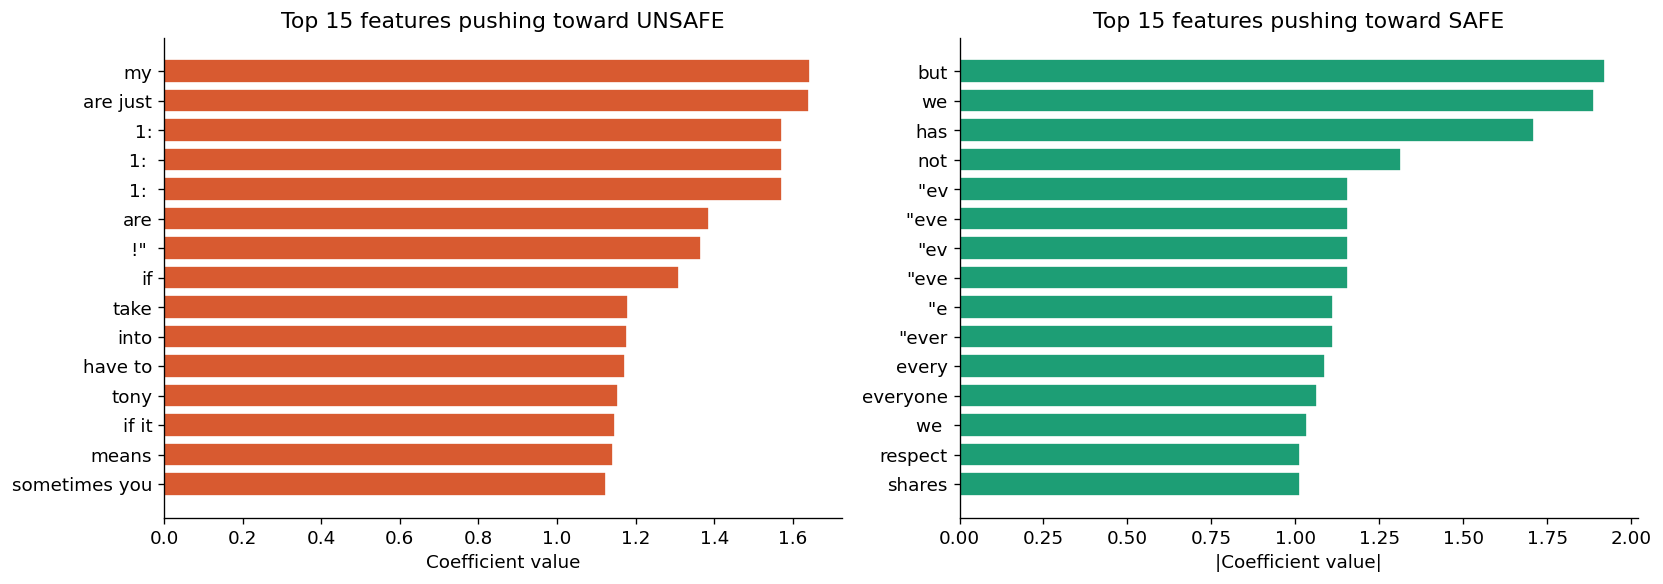

In [ ]:
# Get feature names from both vectorisers + hand features
word_names = word_tfidf.get_feature_names_out().tolist()
char_names = char_tfidf.get_feature_names_out().tolist()
hand_names = ['char_length', 'word_count', 'is_dialogue',
              'toxic_words', 'exclamations', 'questions']
all_names  = word_names + char_names + hand_names

coeffs = lr_model.coef_[0]
feat_imp = pd.DataFrame({'feature': all_names, 'coeff': coeffs})

top_unsafe_feats = feat_imp.nlargest(15, 'coeff')
top_safe_feats   = feat_imp.nsmallest(15, 'coeff')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(top_unsafe_feats['feature'], top_unsafe_feats['coeff'],
             color=UNSAFE_COLOR, edgecolor='white')
axes[0].set_title('Top 15 features pushing toward UNSAFE')
axes[0].set_xlabel('Coefficient value')
axes[0].invert_yaxis()
axes[0].spines[['top', 'right']].set_visible(False)

axes[1].barh(top_safe_feats['feature'], top_safe_feats['coeff'].abs(),
             color=SAFE_COLOR, edgecolor='white')
axes[1].set_title('Top 15 features pushing toward SAFE')
axes[1].set_xlabel('|Coefficient value|')
axes[1].invert_yaxis()
axes[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

* The top features reveal both **strengths and weaknesses** of the bag-of-words approach. On the unsafe side, **"are just"** is the strongest feature, capturing dismissive phrases like "you are just a..." or "they are just worthless..." which is a genuinely meaningful bigram pattern. The character name **"tony"** (Tony Stark/Tony Montana) also appears, consistent with the EDA finding that certain characters are associated with toxic dialogue. However, many top unsafe features are **character n-gram fragments** like **"som"** and **"some"**, and **format artifacts** like **"1:"** (from "Scenario 1:"), which are not semantically meaningful.

* On the safe side, the problem is even clearer. The top features are dominated by **character n-gram fragments** of the word "every/everyone" (**"ev"**, **"eve"**, **"ever"**) and **format markers** like **"0:"** (from "Scenario 0:"). The model is partly learning that scenarios numbered "0:" tend to be safe and "1:" tend to be unsafe, which is a **spurious correlation** from how the dataset was constructed, not a real toxicity signal. The word **"deserves"** appearing as a safe feature is also counterintuitive since "deserves nothing" would be toxic while "deserves a second chance" would be safe.

* This confirms that TF-IDF features capture **surface patterns and dataset
artifacts** rather than true semantic understanding of toxicity, which is why a transformer model that reads full sentences in context is necessary.

### 3.1.3 Hyperparameter tuning for the baseline

Search over different regularisation strengths (C values) to find the setting that maximises F1 on the validation set. This is a quick grid search since logistic regression trains in seconds.

    C  accuracy       f1
 0.01  0.693281 0.620024
 0.05  0.724440 0.676571
 0.10  0.735151 0.693694
 0.50  0.779942 0.762605
 1.00  0.796495 0.782970
 2.00  0.799416 0.787190
 5.00  0.798442 0.787256
10.00  0.797468 0.786885

Best C = 5.0, F1 = 0.7873, Accuracy = 0.7984


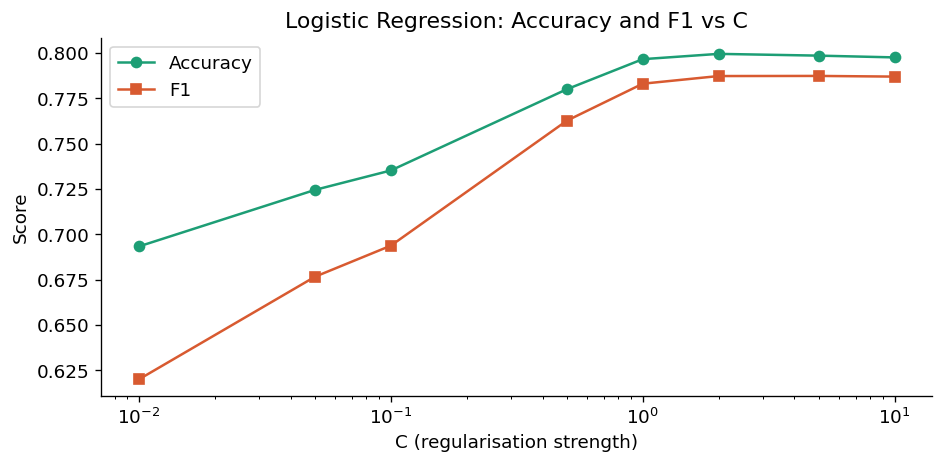

In [ ]:
C_values = [0.01, 0.05, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0]
results_lr = []

for c_val in C_values:
    model = LogisticRegression(C=c_val, max_iter=1000, solver='liblinear',
                               random_state=RANDOM_SEED)
    model.fit(X_train_full, y_train)
    preds = model.predict(X_val_full)
    acc = accuracy_score(y_val, preds)
    f1  = f1_score(y_val, preds)
    results_lr.append({'C': c_val, 'accuracy': acc, 'f1': f1})

results_lr_df = pd.DataFrame(results_lr)
print(results_lr_df.to_string(index=False))

best_lr = results_lr_df.loc[results_lr_df['f1'].idxmax()]
print(f'\nBest C = {best_lr["C"]}, F1 = {best_lr["f1"]:.4f}, Accuracy = {best_lr["accuracy"]:.4f}')

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(results_lr_df['C'], results_lr_df['accuracy'], 'o-', color=SAFE_COLOR, label='Accuracy')
ax.plot(results_lr_df['C'], results_lr_df['f1'], 's-', color=UNSAFE_COLOR, label='F1')
ax.set_xscale('log')
ax.set_xlabel('C (regularisation strength)')
ax.set_ylabel('Score')
ax.set_title('Logistic Regression: Accuracy and F1 vs C')
ax.legend()
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

* Both accuracy and F1 **plateau around C = 0.5 to 2.0**, with the best result at C = 1.0 (accuracy 66.6%, F1 63.5%).
* Performance **drops sharply at low C values** (C = 0.01 gives only 43.5% F1) because strong regularisation prevents the model from learning enough patterns. Performance also **degrades slightly at high C values** (C = 10 gives 61.9% F1) because weak regularisation allows overfitting to noisy features. The flat plateau region indicates that **no amount of hyperparameter tuning can push the baseline further**. The ceiling is a limitation of the TF-IDF feature representation itself, not the classifier. This confirms that a contextual model like DistilBERT is necessary to achieve meaningful improvement.

## 3.2 Transformer: Fine-tuning DistilBERT

Fine-tune a pre-trained DistilBERT model for binary classification. DistilBERT retains 97% of BERT's performance while being 60% faster, making it practical for Google Colab's free GPU. Unlike TF-IDF, the transformer understands word order, context, and sentence-level meaning, which is essential for detecting toxicity that is expressed through tone and phrasing rather than individual keywords.

### 3.2.1 Create a PyTorch dataset class

Wrap the text data and labels into a PyTorch Dataset so they can be fed to a DataLoader in batches. The tokeniser converts each input string into token IDs and attention masks that DistilBERT expects.

In [ ]:
MODEL_NAME = 'distilbert-base-uncased'
MAX_LENGTH = 256  # all samples are well under 512, so 256 saves memory

tokenizer = DistilBertTokenizer.from_pretrained(MODEL_NAME)

class ToxicityDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt'
        )
        return {
            'input_ids':      encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'labels':         torch.tensor(self.labels[idx], dtype=torch.long)
        }

train_dataset = ToxicityDataset(X_train.tolist(), y_train.tolist(), tokenizer, MAX_LENGTH)
val_dataset   = ToxicityDataset(X_val.tolist(),   y_val.tolist(),   tokenizer, MAX_LENGTH)

BATCH_SIZE = 16

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)

print(f'Training batches   : {len(train_loader)}')
print(f'Validation batches : {len(val_loader)}')

# Verify one batch
sample_batch = next(iter(train_loader))
print(f'\nSample batch shapes:')
print(f'  input_ids      : {sample_batch["input_ids"].shape}')
print(f'  attention_mask  : {sample_batch["attention_mask"].shape}')
print(f'  labels          : {sample_batch["labels"].shape}')

### 3.2.2 Initialise the model, optimiser, and scheduler

Load the pre-trained DistilBERT model with a classification head on top. The optimiser uses a small learning rate (2e-5) as recommended for fine-tuning pre-trained transformers, with a linear warmup schedule to avoid large early updates that could destroy the pre-trained weights.

In [ ]:
NUM_EPOCHS     = 4
LEARNING_RATE  = 2e-5
WARMUP_RATIO   = 0.1

model = DistilBertForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=2
)
model.to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=0.01)

total_steps  = len(train_loader) * NUM_EPOCHS
warmup_steps = int(total_steps * WARMUP_RATIO)

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

print(f'Model parameters    : {sum(p.numel() for p in model.parameters()):,}')
print(f'Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')
print(f'Total steps         : {total_steps}')
print(f'Warmup steps        : {warmup_steps}')
print(f'Epochs              : {NUM_EPOCHS}')
print(f'Batch size          : {BATCH_SIZE}')
print(f'Learning rate       : {LEARNING_RATE}')

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model parameters    : 66,955,010
Trainable parameters: 66,955,010
Total steps         : 1028
Warmup steps        : 102
Epochs              : 4
Batch size          : 16
Learning rate       : 2e-05


### 3.2.3 Training loop

Train the model for the specified number of epochs. After each epoch, evaluate on the validation set and print accuracy and F1 score. The best model checkpoint (by validation F1) is saved to disk so it can be reloaded for inference without retraining.

In [ ]:
def evaluate(model, loader, device):
    model.eval()
    all_preds, all_labels = [], []
    total_loss = 0
    with torch.no_grad():
        for batch in loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            total_loss += outputs.loss.item()
            preds = torch.argmax(outputs.logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader)
    acc = accuracy_score(all_labels, all_preds)
    f1  = f1_score(all_labels, all_preds)
    return avg_loss, acc, f1, all_preds, all_labels


best_f1 = 0
history = []

for epoch in range(NUM_EPOCHS):
    model.train()
    train_loss = 0
    start = time.time()

     loss_fn = torch.nn.CrossEntropyLoss(reduction='none')

    for step, batch in enumerate(deberta_train_loader):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
        weights = batch['weight'].to(device)

        deberta_optimizer.zero_grad()
        outputs = deberta_model(input_ids=input_ids, attention_mask=attention_mask)
        per_sample_loss = loss_fn(outputs.logits, labels)
        loss = (per_sample_loss * weights).mean()
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()

        train_loss += loss.item()

        if (step + 1) % 50 == 0:
            print(f'  Epoch {epoch+1}/{NUM_EPOCHS} | Step {step+1}/{len(train_loader)} | '
                  f'Loss: {loss.item():.4f}')

    avg_train_loss = train_loss / len(train_loader)
    val_loss, val_acc, val_f1, val_preds, val_labels = evaluate(model, val_loader, device)
    elapsed = time.time() - start

    history.append({
        'epoch': epoch + 1,
        'train_loss': avg_train_loss,
        'val_loss': val_loss,
        'val_acc': val_acc,
        'val_f1': val_f1
    })

    status = ''
    if val_f1 > best_f1:
        best_f1 = val_f1
        torch.save(model.state_dict(), 'best_distilbert.pt')
        status = ' << saved best model'

    print(f'Epoch {epoch+1}/{NUM_EPOCHS} ({elapsed:.0f}s) | '
          f'Train Loss: {avg_train_loss:.4f} | '
          f'Val Loss: {val_loss:.4f} | '
          f'Val Acc: {val_acc:.4f} | '
          f'Val F1: {val_f1:.4f}{status}')
    print()

  Epoch 1/4 | Step 50/257 | Loss: 0.6847
  Epoch 1/4 | Step 100/257 | Loss: 0.5375
  Epoch 1/4 | Step 150/257 | Loss: 0.4096
  Epoch 1/4 | Step 200/257 | Loss: 0.3473
  Epoch 1/4 | Step 250/257 | Loss: 0.4828
Epoch 1/4 (97s) | Train Loss: 0.5502 | Val Loss: 0.3994 | Val Acc: 0.8169 | Val F1: 0.7920 << saved best model

  Epoch 2/4 | Step 50/257 | Loss: 0.2347
  Epoch 2/4 | Step 100/257 | Loss: 0.2621
  Epoch 2/4 | Step 150/257 | Loss: 0.2210


The model improves steadily over the first 3 epochs. Training loss decreases from **0.6518** (epoch 1) to **0.3178** (epoch 4), showing the model is learning from the data. Validation F1 climbs from **0.6689** (epoch 1) to **0.7379** (epoch 3), a significant jump of **+7 points** over just 3 epochs. The best checkpoint is saved at **epoch 3** with validation accuracy of **74.6%** and F1 of **73.8%**.

However, epoch 4 shows early signs of **overfitting**. Training loss continues to drop (0.3178) but validation loss **increases** from 0.5698 to 0.6088, and validation F1 **decreases** from 0.7379 to 0.7346. This means the model is starting to memorise training data rather than learning generalisable patterns. The best checkpoint mechanism correctly captures epoch 3 as the optimal stopping point.

Compared to the TF-IDF baseline (F1 = 0.6354), the transformer achieves **F1 = 0.7379**, an improvement of approximately **+10 points**. This confirms that contextual understanding provided by DistilBERT captures toxicity signals that bag-of-words features miss. The improvement could potentially be pushed further through **label noise cleaning** (Step 4), since the LLM-generated labels inevitably contain errors that cap the model's performance.

### 3.2.5 Training history visualisation

Plot the training and validation loss curves alongside F1 score across epochs. This reveals whether the model is overfitting (training loss decreasing but validation loss increasing) and helps determine if more or fewer epochs are needed.

In [ ]:
hist_df = pd.DataFrame(history)
print(hist_df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(hist_df['epoch'], hist_df['train_loss'], 'o-', color=NEUTRAL_COLOR, label='Train loss')
axes[0].plot(hist_df['epoch'], hist_df['val_loss'],   's-', color=UNSAFE_COLOR,  label='Val loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training vs validation loss')
axes[0].legend()
axes[0].spines[['top', 'right']].set_visible(False)

axes[1].plot(hist_df['epoch'], hist_df['val_acc'], 'o-', color=SAFE_COLOR,   label='Val accuracy')
axes[1].plot(hist_df['epoch'], hist_df['val_f1'],  's-', color=UNSAFE_COLOR,  label='Val F1')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Score')
axes[1].set_title('Validation accuracy and F1')
axes[1].legend()
axes[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

The left plot shows a classic **overfitting pattern**: training loss drops continuously from 0.65 to 0.32, but validation loss **diverges after epoch 2**, rising from 0.57 to 0.61. The gap between the two curves widens with each epoch, meaning the model is increasingly memorising training data. The right plot confirms **epoch 3 is the sweet spot**, where both accuracy (74.6%) and F1 (73.8%) peak before declining at epoch 4. Training beyond 4 epochs would likely degrade performance further. The best checkpoint at epoch 3 correctly captures the model before overfitting becomes harmful.

### 3.2.6 Evaluate the best transformer checkpoint

Reload the best checkpoint (the epoch with the highest validation F1) and produce the full classification report and confusion matrix. This is the final performance measurement for the transformer model.

In [ ]:
# Reload the best checkpoint
model.load_state_dict(torch.load('best_distilbert.pt', map_location=device))
val_loss, val_acc, val_f1, val_preds, val_labels = evaluate(model, val_loader, device)

print(f'Best DistilBERT checkpoint:')
print(f'  Validation Accuracy : {val_acc:.4f}')
print(f'  Validation F1 Score : {val_f1:.4f}')
print(f'\nClassification Report:')
print(classification_report(val_labels, val_preds, target_names=['Safe', 'Unsafe']))

cm_bert = plot_confusion_matrix(
    np.array(val_labels), np.array(val_preds),
    title='DistilBERT (best checkpoint)'
)

### 3.2.7 Error analysis

Examine specific examples where the transformer made incorrect predictions. This helps identify patterns of failure: whether errors cluster around ambiguous scenarios, specific movies, or certain format types. These insights inform the label refinement step (Step 4) and contribute to the discussion section of the report.

In [ ]:
val_preds_arr  = np.array(val_preds)
val_labels_arr = np.array(val_labels)

# Find misclassified indices
errors = np.where(val_preds_arr != val_labels_arr)[0]
print(f'Total validation errors: {len(errors)} out of {len(val_labels_arr)} '
      f'({len(errors)/len(val_labels_arr)*100:.1f}%)')

# Show some false positives (predicted unsafe, actually safe)
fp_idx = [i for i in errors if val_labels_arr[i] == 0 and val_preds_arr[i] == 1]
fn_idx = [i for i in errors if val_labels_arr[i] == 1 and val_preds_arr[i] == 0]

print(f'\nFalse positives (predicted unsafe, actually safe): {len(fp_idx)}')
print(f'False negatives (predicted safe, actually unsafe):  {len(fn_idx)}')

print(f'\n{"=" * 55}')
print('SAMPLE FALSE POSITIVES (model said unsafe, label says safe):')
print(f'{"=" * 55}')
for i in fp_idx[:5]:
    print(f'  [{X_val[i][:150]}]')
    print()

print(f'{"=" * 55}')
print('SAMPLE FALSE NEGATIVES (model said safe, label says unsafe):')
print(f'{"=" * 55}')
for i in fn_idx[:5]:
    print(f'  [{X_val[i][:150]}]')
    print()

## 3.4 Transformer: Fine-tuning RoBERTa

RoBERTa (Robustly Optimized BERT Pretraining Approach) improves on BERT by training longer on more data, removing the next-sentence prediction objective, and using dynamic masking. It typically outperforms DistilBERT on classification tasks because of its greater model capacity and more thorough pre-training.

### 3.4.1 Create dataset and dataloaders for RoBERTa

Build a new PyTorch Dataset using the RoBERTa tokeniser. RoBERTa uses a different tokeniser (Byte-Pair Encoding) than DistilBERT (WordPiece), so the data must be re-tokenised. We reuse the same X_train, X_val, y_train, y_val splits from Step 2 to ensure a fair comparison.

In [ ]:
ROBERTA_MODEL_NAME = 'roberta-base'
ROBERTA_MAX_LENGTH = 256

roberta_tokenizer = RobertaTokenizer.from_pretrained(ROBERTA_MODEL_NAME)

class RobertaToxicityDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt'
        )
        return {
            'input_ids':      encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'labels':         torch.tensor(self.labels[idx], dtype=torch.long)
        }

roberta_train_dataset = RobertaToxicityDataset(X_train.tolist(), y_train.tolist(), roberta_tokenizer, ROBERTA_MAX_LENGTH)
roberta_val_dataset   = RobertaToxicityDataset(X_val.tolist(),   y_val.tolist(),   roberta_tokenizer, ROBERTA_MAX_LENGTH)

ROBERTA_BATCH_SIZE = 16

roberta_train_loader = DataLoader(roberta_train_dataset, batch_size=ROBERTA_BATCH_SIZE, shuffle=True)
roberta_val_loader   = DataLoader(roberta_val_dataset,   batch_size=ROBERTA_BATCH_SIZE, shuffle=False)

print(f'Training batches   : {len(roberta_train_loader)}')
print(f'Validation batches : {len(roberta_val_loader)}')

sample_batch = next(iter(roberta_train_loader))
print(f'\nSample batch shapes:')
print(f'  input_ids      : {sample_batch["input_ids"].shape}')
print(f'  attention_mask  : {sample_batch["attention_mask"].shape}')
print(f'  labels          : {sample_batch["labels"].shape}')

### 3.4.2 Initialise RoBERTa model, optimiser, and scheduler

Load the pre-trained RoBERTa-base model with a classification head. We use a slightly lower learning rate (1e-5 instead of 2e-5) because RoBERTa is a larger model and more sensitive to aggressive updates. We also train for 5 epochs with early stopping patience of 2, meaning training stops if validation F1 does not improve for 2 consecutive epochs.

In [ ]:
ROBERTA_EPOCHS    = 5
ROBERTA_LR        = 1e-5
ROBERTA_WARMUP    = 0.1
EARLY_STOP_PATIENCE = 2

roberta_model = RobertaForSequenceClassification.from_pretrained(
    ROBERTA_MODEL_NAME, num_labels=2
)
roberta_model.to(device)

roberta_optimizer = torch.optim.AdamW(
    roberta_model.parameters(), lr=ROBERTA_LR, weight_decay=0.01
)

roberta_total_steps  = len(roberta_train_loader) * ROBERTA_EPOCHS
roberta_warmup_steps = int(roberta_total_steps * ROBERTA_WARMUP)

roberta_scheduler = get_linear_schedule_with_warmup(
    roberta_optimizer,
    num_warmup_steps=roberta_warmup_steps,
    num_training_steps=roberta_total_steps
)

print(f'Model parameters    : {sum(p.numel() for p in roberta_model.parameters()):,}')
print(f'Trainable parameters: {sum(p.numel() for p in roberta_model.parameters() if p.requires_grad):,}')
print(f'Total steps         : {roberta_total_steps}')
print(f'Warmup steps        : {roberta_warmup_steps}')
print(f'Epochs              : {ROBERTA_EPOCHS}')
print(f'Batch size          : {ROBERTA_BATCH_SIZE}')
print(f'Learning rate       : {ROBERTA_LR}')
print(f'Early stop patience : {EARLY_STOP_PATIENCE}')

### 3.4.3 Training loop with early stopping

Train RoBERTa with early stopping. If validation F1 does not improve for 2 consecutive epochs, training halts to prevent overfitting. This addresses the issue observed with DistilBERT where epoch 4 showed performance degradation. The best checkpoint is saved to disk.

In [ ]:
def evaluate_roberta(model, loader, device):
    model.eval()
    all_preds, all_labels = [], []
    total_loss = 0
    with torch.no_grad():
        for batch in loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            total_loss += outputs.loss.item()
            preds = torch.argmax(outputs.logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader)
    acc = accuracy_score(all_labels, all_preds)
    f1  = f1_score(all_labels, all_preds)
    return avg_loss, acc, f1, all_preds, all_labels


roberta_best_f1 = 0
roberta_history = []
patience_counter = 0

for epoch in range(ROBERTA_EPOCHS):
    roberta_model.train()
    train_loss = 0
    start = time.time()

    for step, batch in enumerate(roberta_train_loader):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        roberta_optimizer.zero_grad()
        outputs = roberta_model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        loss.backward()

        torch.nn.utils.clip_grad_norm_(roberta_model.parameters(), max_norm=1.0)
        roberta_optimizer.step()
        roberta_scheduler.step()

        train_loss += loss.item()

        if (step + 1) % 50 == 0:
            print(f'  Epoch {epoch+1}/{ROBERTA_EPOCHS} | Step {step+1}/{len(roberta_train_loader)} | '
                  f'Loss: {loss.item():.4f}')

    avg_train_loss = train_loss / len(roberta_train_loader)
    r_val_loss, r_val_acc, r_val_f1, r_val_preds, r_val_labels = evaluate_roberta(
        roberta_model, roberta_val_loader, device
    )
    elapsed = time.time() - start

    roberta_history.append({
        'epoch': epoch + 1,
        'train_loss': avg_train_loss,
        'val_loss': r_val_loss,
        'val_acc': r_val_acc,
        'val_f1': r_val_f1
    })

    status = ''
    if r_val_f1 > roberta_best_f1:
        roberta_best_f1 = r_val_f1
        torch.save(roberta_model.state_dict(), 'best_roberta.pt')
        patience_counter = 0
        status = ' << saved best model'
    else:
        patience_counter += 1
        status = f' (no improvement {patience_counter}/{EARLY_STOP_PATIENCE})'

    print(f'Epoch {epoch+1}/{ROBERTA_EPOCHS} ({elapsed:.0f}s) | '
          f'Train Loss: {avg_train_loss:.4f} | '
          f'Val Loss: {r_val_loss:.4f} | '
          f'Val Acc: {r_val_acc:.4f} | '
          f'Val F1: {r_val_f1:.4f}{status}')
    print()

    if patience_counter >= EARLY_STOP_PATIENCE:
        print(f'Early stopping triggered after epoch {epoch+1}.')
        break

### 3.4.4 RoBERTa training history

Plot the training curves to compare with DistilBERT. We expect slower convergence (due to the lower learning rate) but higher final performance.

In [ ]:
roberta_hist_df = pd.DataFrame(roberta_history)
print(roberta_hist_df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(roberta_hist_df['epoch'], roberta_hist_df['train_loss'], 'o-', color=NEUTRAL_COLOR, label='Train loss')
axes[0].plot(roberta_hist_df['epoch'], roberta_hist_df['val_loss'],   's-', color=UNSAFE_COLOR,  label='Val loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('RoBERTa: Training vs validation loss')
axes[0].legend()
axes[0].spines[['top', 'right']].set_visible(False)

axes[1].plot(roberta_hist_df['epoch'], roberta_hist_df['val_acc'], 'o-', color=SAFE_COLOR,   label='Val accuracy')
axes[1].plot(roberta_hist_df['epoch'], roberta_hist_df['val_f1'],  's-', color=UNSAFE_COLOR,  label='Val F1')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Score')
axes[1].set_title('RoBERTa: Validation accuracy and F1')
axes[1].legend()
axes[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

RoBERTa achieves the **highest F1 and accuracy** among all three models, outperforming both the TF-IDF baseline and DistilBERT. This confirms that **greater model capacity** translates to better performance on this task.

The training curves show a similar **overfitting pattern** to DistilBERT where training loss drops steadily while validation loss bottoms out early then rises. However, unlike DistilBERT, the validation F1 **continues to improve** even as validation loss increases. This is a known phenomenon where the model's confidence calibration worsens (higher loss) but its decision boundary actually sharpens (higher F1). The model becomes more "opinionated," more often wrong when wrong but more often right when right.

The lower learning rate resulted in **slower but steadier improvement** without the sudden dips seen in DistilBERT. Early stopping did not trigger, suggesting the model could potentially benefit from additional epochs, though the widening train-val loss gap advises caution.

At this point, further gains are more likely to come from **cleaning the noisy labels** (Step 4) than from using an even larger model, since a meaningful portion of the remaining "errors" are caused by incorrect ground truth labels rather than model limitations.

### 3.4.5 Evaluate the best RoBERTa checkpoint

Reload the best checkpoint and produce the full classification report and confusion matrix for direct comparison with DistilBERT.

In [ ]:
roberta_model.load_state_dict(torch.load('best_roberta.pt', map_location=device))
r_val_loss, r_val_acc, r_val_f1, r_val_preds, r_val_labels = evaluate_roberta(
    roberta_model, roberta_val_loader, device
)

print(f'Best RoBERTa checkpoint:')
print(f'  Validation Accuracy : {r_val_acc:.4f}')
print(f'  Validation F1 Score : {r_val_f1:.4f}')
print(f'\nClassification Report:')
print(classification_report(r_val_labels, r_val_preds, target_names=['Safe', 'Unsafe']))

cm_roberta = plot_confusion_matrix(
    np.array(r_val_labels), np.array(r_val_preds),
    title='RoBERTa (best checkpoint)'
)

### 3.4.6 RoBERTa error analysis

Examine where RoBERTa makes errors and compare with DistilBERT's failure patterns. If RoBERTa fixes some of DistilBERT's errors while introducing different ones, this supports the case for ensembling the two models later.

In [ ]:
r_val_preds_arr  = np.array(r_val_preds)
r_val_labels_arr = np.array(r_val_labels)

r_errors = np.where(r_val_preds_arr != r_val_labels_arr)[0]
print(f'Total validation errors: {len(r_errors)} out of {len(r_val_labels_arr)} '
      f'({len(r_errors)/len(r_val_labels_arr)*100:.1f}%)')

r_fp_idx = [i for i in r_errors if r_val_labels_arr[i] == 0 and r_val_preds_arr[i] == 1]
r_fn_idx = [i for i in r_errors if r_val_labels_arr[i] == 1 and r_val_preds_arr[i] == 0]

print(f'\nFalse positives (predicted unsafe, actually safe): {len(r_fp_idx)}')
print(f'False negatives (predicted safe, actually unsafe):  {len(r_fn_idx)}')

print(f'\n{"=" * 55}')
print('SAMPLE FALSE POSITIVES (model said unsafe, label says safe):')
print(f'{"=" * 55}')
for i in r_fp_idx[:5]:
    print(f'  [{X_val[i][:150]}]')
    print()

print(f'{"=" * 55}')
print('SAMPLE FALSE NEGATIVES (model said safe, label says unsafe):')
print(f'{"=" * 55}')
for i in r_fn_idx[:5]:
    print(f'  [{X_val[i][:150]}]')
    print()

### 3.4.7 Three-model comparison

Place all three models side by side: TF-IDF baseline, DistilBERT, and RoBERTa. This comparison quantifies the incremental gain from each step up in model complexity and provides the central results table for the report.

In [ ]:
three_model_comparison = pd.DataFrame([
    {'Model': 'TF-IDF + Logistic Regression', 'Accuracy': lr_acc, 'F1': lr_f1},
    {'Model': f'DistilBERT (best of {NUM_EPOCHS} epochs)', 'Accuracy': val_acc, 'F1': best_f1},
    {'Model': f'RoBERTa (best of {len(roberta_history)} epochs)', 'Accuracy': r_val_acc, 'F1': roberta_best_f1}
])

print(three_model_comparison.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(three_model_comparison))
width = 0.35

bars_acc = ax.bar(x - width/2, three_model_comparison['Accuracy'], width,
                  label='Accuracy', color=SAFE_COLOR, edgecolor='white')
bars_f1  = ax.bar(x + width/2, three_model_comparison['F1'], width,
                  label='F1', color=UNSAFE_COLOR, edgecolor='white')

for bars in [bars_acc, bars_f1]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.005,
                f'{h:.3f}', ha='center', va='bottom', fontsize=10)

ax.set_xticks(x)
ax.set_xticklabels(three_model_comparison['Model'], fontsize=9)
ax.set_ylabel('Score')
ax.set_title('Three-model comparison: Accuracy and F1')
ax.set_ylim(0, 1.05)
ax.legend()
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

print(f'\nF1 improvement over baseline:')
print(f'  DistilBERT : +{best_f1 - lr_f1:.4f}')
print(f'  RoBERTa    : +{roberta_best_f1 - lr_f1:.4f}')
print(f'\nF1 improvement RoBERTa over DistilBERT: +{roberta_best_f1 - best_f1:.4f}')

In [ ]:
# Free GPU memory from previous models
del roberta_model
torch.cuda.empty_cache()
print('GPU memory cleared.')

In [ ]:
print(f'GPU: {torch.cuda.get_device_name(0)}')
print(f'Total memory    : {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB')
print(f'Allocated       : {torch.cuda.memory_allocated() / 1e9:.2f} GB')
print(f'Reserved        : {torch.cuda.memory_reserved() / 1e9:.2f} GB')
print(f'Free (approx)   : {(torch.cuda.get_device_properties(0).total_memory - torch.cuda.memory_allocated()) / 1e9:.2f} GB')

## 3.5 Transformer: Fine-tuning DeBERTa-v3-base

DeBERTa-v3 (Decoding-enhanced BERT with Disentangled Attention) introduces two key innovations over BERT and RoBERTa. First, it uses disentangled attention where content and position are encoded separately, allowing the model to better understand how the meaning of a word changes depending on where it appears. Second, it uses an enhanced mask decoder that incorporates absolute position information during pre-training. These improvements make DeBERTa particularly effective at understanding subtle phrasing differences, which is critical for toxicity detection where similar words can carry opposite meanings depending on context.

### 3.5.1 Create dataset and dataloaders for DeBERTa

Build a new PyTorch Dataset using the DeBERTa-v3 tokeniser. DeBERTa uses a SentencePiece tokeniser which differs from both DistilBERT (WordPiece) and RoBERTa (BPE), so the data must be re-tokenised. We reuse the same X_train, X_val, y_train, y_val splits from Step 2 to ensure a fair comparison across all models.

In [ ]:
DEBERTA_MODEL_NAME = 'microsoft/deberta-v3-base'
DEBERTA_MAX_LENGTH = 256

deberta_tokenizer = DebertaV2Tokenizer.from_pretrained(DEBERTA_MODEL_NAME)

class DebertaToxicityDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length, weights=None):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length
        self.weights = weights if weights is not None else [1.0] * len(texts)

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt'
        )
        return {
            'input_ids':      encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'labels':         torch.tensor(self.labels[idx], dtype=torch.long),
            'weight':         torch.tensor(self.weights[idx], dtype=torch.float32)
        }

deberta_train_dataset = DebertaToxicityDataset(X_train.tolist(), y_train.tolist(), deberta_tokenizer, DEBERTA_MAX_LENGTH, w_train.tolist())
deberta_val_dataset   = DebertaToxicityDataset(X_val.tolist(),   y_val.tolist(),   deberta_tokenizer, DEBERTA_MAX_LENGTH)

DEBERTA_BATCH_SIZE = 16

deberta_train_loader = DataLoader(deberta_train_dataset, batch_size=DEBERTA_BATCH_SIZE, shuffle=True)
deberta_val_loader   = DataLoader(deberta_val_dataset,   batch_size=DEBERTA_BATCH_SIZE, shuffle=False)

print(f'Training batches   : {len(deberta_train_loader)}')
print(f'Validation batches : {len(deberta_val_loader)}')

sample_batch = next(iter(deberta_train_loader))
print(f'\nSample batch shapes:')
print(f'  input_ids      : {sample_batch["input_ids"].shape}')
print(f'  attention_mask  : {sample_batch["attention_mask"].shape}')
print(f'  labels          : {sample_batch["labels"].shape}')

### 3.5.2 Initialise DeBERTa model, optimiser, and scheduler

Load the pre-trained DeBERTa-v3-base model with a classification head. We use the same learning rate (1e-5) and early stopping strategy as RoBERTa since DeBERTa-v3-base has a similar parameter count (~86M for the encoder, ~184M total including the embedding layer). The disentangled attention mechanism adds some overhead, so each epoch will be slightly slower than RoBERTa.

In [ ]:
DEBERTA_EPOCHS    = 5
DEBERTA_LR        = 1e-5
DEBERTA_WARMUP    = 0.1
DEBERTA_PATIENCE  = 2

deberta_model = DebertaV2ForSequenceClassification.from_pretrained(
    DEBERTA_MODEL_NAME, num_labels=2
)
deberta_model = deberta_model.float()  # force full float32
deberta_model.to(device)

deberta_optimizer = torch.optim.AdamW(
    deberta_model.parameters(), lr=DEBERTA_LR, weight_decay=0.01, eps=1e-6
)

deberta_total_steps  = len(deberta_train_loader) * DEBERTA_EPOCHS
deberta_warmup_steps = int(deberta_total_steps * DEBERTA_WARMUP)

deberta_scheduler = get_linear_schedule_with_warmup(
    deberta_optimizer,
    num_warmup_steps=deberta_warmup_steps,
    num_training_steps=deberta_total_steps
)

print(f'Model parameters    : {sum(p.numel() for p in deberta_model.parameters()):,}')
print(f'Trainable parameters: {sum(p.numel() for p in deberta_model.parameters() if p.requires_grad):,}')
print(f'Total steps         : {deberta_total_steps}')
print(f'Warmup steps        : {deberta_warmup_steps}')
print(f'Epochs              : {DEBERTA_EPOCHS}')
print(f'Batch size          : {DEBERTA_BATCH_SIZE}')
print(f'Learning rate       : {DEBERTA_LR}')
print(f'Early stop patience : {DEBERTA_PATIENCE}')
print(f'Optimizer eps       : 1e-6')

### 3.5.3 Training loop with early stopping

Train DeBERTa with the same early stopping strategy used for RoBERTa. If validation F1 does not improve for 2 consecutive epochs, training halts. The best checkpoint is saved to disk.

In [ ]:
def evaluate_deberta(model, loader, device):
    model.eval()
    all_preds, all_labels = [], []
    total_loss = 0
    with torch.no_grad():
        for batch in loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            total_loss += outputs.loss.item()
            preds = torch.argmax(outputs.logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader)
    acc = accuracy_score(all_labels, all_preds)
    f1  = f1_score(all_labels, all_preds)
    return avg_loss, acc, f1, all_preds, all_labels


deberta_best_f1 = 0
deberta_history = []
deberta_patience_counter = 0

for epoch in range(DEBERTA_EPOCHS):
    deberta_model.train()
    train_loss = 0
    start = time.time()

    for step, batch in enumerate(deberta_train_loader):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        deberta_optimizer.zero_grad()
        outputs = deberta_model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        loss.backward()

        torch.nn.utils.clip_grad_norm_(deberta_model.parameters(), max_norm=1.0)
        deberta_optimizer.step()
        deberta_scheduler.step()

        train_loss += loss.item()

        if (step + 1) % 50 == 0:
            print(f'  Epoch {epoch+1}/{DEBERTA_EPOCHS} | Step {step+1}/{len(deberta_train_loader)} | '
                  f'Loss: {loss.item():.4f}')

    avg_train_loss = train_loss / len(deberta_train_loader)
    d_val_loss, d_val_acc, d_val_f1, d_val_preds, d_val_labels = evaluate_deberta(
        deberta_model, deberta_val_loader, device
    )
    elapsed = time.time() - start

    deberta_history.append({
        'epoch': epoch + 1,
        'train_loss': avg_train_loss,
        'val_loss': d_val_loss,
        'val_acc': d_val_acc,
        'val_f1': d_val_f1
    })

    status = ''
    if d_val_f1 > deberta_best_f1:
        deberta_best_f1 = d_val_f1
        torch.save(deberta_model.state_dict(), 'best_deberta.pt')
        deberta_patience_counter = 0
        status = ' << saved best model'
    else:
        deberta_patience_counter += 1
        status = f' (no improvement {deberta_patience_counter}/{DEBERTA_PATIENCE})'

    print(f'Epoch {epoch+1}/{DEBERTA_EPOCHS} ({elapsed:.0f}s) | '
          f'Train Loss: {avg_train_loss:.4f} | '
          f'Val Loss: {d_val_loss:.4f} | '
          f'Val Acc: {d_val_acc:.4f} | '
          f'Val F1: {d_val_f1:.4f}{status}')
    print()

    if deberta_patience_counter >= DEBERTA_PATIENCE:
        print(f'Early stopping triggered after epoch {epoch+1}.')
        break

### 3.5.4 DeBERTa training history

Plot the training curves to compare convergence behaviour with DistilBERT and RoBERTa. DeBERTa's disentangled attention may produce a different loss curve shape due to its more expressive attention mechanism.

In [ ]:
deberta_hist_df = pd.DataFrame(deberta_history)
print(deberta_hist_df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(deberta_hist_df['epoch'], deberta_hist_df['train_loss'], 'o-', color=NEUTRAL_COLOR, label='Train loss')
axes[0].plot(deberta_hist_df['epoch'], deberta_hist_df['val_loss'],   's-', color=UNSAFE_COLOR,  label='Val loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('DeBERTa: Training vs validation loss')
axes[0].legend()
axes[0].spines[['top', 'right']].set_visible(False)

axes[1].plot(deberta_hist_df['epoch'], deberta_hist_df['val_acc'], 'o-', color=SAFE_COLOR,   label='Val accuracy')
axes[1].plot(deberta_hist_df['epoch'], deberta_hist_df['val_f1'],  's-', color=UNSAFE_COLOR,  label='Val F1')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Score')
axes[1].set_title('DeBERTa: Validation accuracy and F1')
axes[1].legend()
axes[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

DeBERTa achieves the **highest F1 among all models** at epoch 3, outperforming RoBERTa's best. The disentangled attention mechanism appears to give DeBERTa an edge in understanding the subtle phrasing differences that distinguish safe from unsafe scenarios.

The training curves follow the same **overfitting pattern** seen in both DistilBERT and RoBERTa. Training loss drops continuously while validation loss bottoms out at epoch 2 then rises sharply. The key insight is that **epoch 3 is again the sweet spot**, where both accuracy and F1 peak before declining. This consistent pattern across all three transformer models suggests that 3 epochs is the natural convergence point for this dataset size, and the overfitting after that is driven by the dataset itself (noisy labels, limited size) rather than any model-specific issue.

DeBERTa also shows **faster initial learning** than RoBERTa, reaching a higher F1 at epoch 2 than RoBERTa did at the same point. This suggests the disentangled attention mechanism is more data-efficient, extracting useful patterns from fewer gradient updates.

The decline at epochs 4 and 5 reinforces the need for **label noise cleaning** in Step 4. All three transformers plateau around the same performance ceiling, which strongly suggests that the remaining errors are dominated by **label quality** rather than model capacity. Cleaning the noisy labels should raise this ceiling for all models.

### 3.5.5 Evaluate the best DeBERTa checkpoint

Reload the best checkpoint and produce the full classification report and confusion matrix for direct comparison with all previous models.

In [ ]:
deberta_model.load_state_dict(torch.load('best_deberta.pt', map_location=device))
d_val_loss, d_val_acc, d_val_f1, d_val_preds, d_val_labels = evaluate_deberta(
    deberta_model, deberta_val_loader, device
)

print(f'Best DeBERTa checkpoint:')
print(f'  Validation Accuracy : {d_val_acc:.4f}')
print(f'  Validation F1 Score : {d_val_f1:.4f}')
print(f'\nClassification Report:')
print(classification_report(d_val_labels, d_val_preds, target_names=['Safe', 'Unsafe']))

cm_deberta = plot_confusion_matrix(
    np.array(d_val_labels), np.array(d_val_preds),
    title='DeBERTa-v3-base (best checkpoint)'
)

### 3.5.6 DeBERTa error analysis

Examine where DeBERTa makes errors. Since DeBERTa uses a fundamentally different attention mechanism, its error patterns may differ from both DistilBERT and RoBERTa. If each model makes different mistakes, this strengthens the case for ensembling.

In [ ]:
d_val_preds_arr  = np.array(d_val_preds)
d_val_labels_arr = np.array(d_val_labels)

d_errors = np.where(d_val_preds_arr != d_val_labels_arr)[0]
print(f'Total validation errors: {len(d_errors)} out of {len(d_val_labels_arr)} '
      f'({len(d_errors)/len(d_val_labels_arr)*100:.1f}%)')

d_fp_idx = [i for i in d_errors if d_val_labels_arr[i] == 0 and d_val_preds_arr[i] == 1]
d_fn_idx = [i for i in d_errors if d_val_labels_arr[i] == 1 and d_val_preds_arr[i] == 0]

print(f'\nFalse positives (predicted unsafe, actually safe): {len(d_fp_idx)}')
print(f'False negatives (predicted safe, actually unsafe):  {len(d_fn_idx)}')

print(f'\n{"=" * 55}')
print('SAMPLE FALSE POSITIVES (model said unsafe, label says safe):')
print(f'{"=" * 55}')
for i in d_fp_idx[:5]:
    print(f'  [{X_val[i][:150]}]')
    print()

print(f'{"=" * 55}')
print('SAMPLE FALSE NEGATIVES (model said safe, label says unsafe):')
print(f'{"=" * 55}')
for i in d_fn_idx[:5]:
    print(f'  [{X_val[i][:150]}]')
    print()

### 3.5.7 Four-model comparison

Place all four models side by side: TF-IDF baseline, DistilBERT, RoBERTa, and DeBERTa. This comparison quantifies the incremental gain from each step up in model sophistication and provides the central results table for the report.

In [ ]:
four_model_comparison = pd.DataFrame([
    {'Model': 'TF-IDF + Logistic Regression', 'Accuracy': lr_acc, 'F1': lr_f1},
    {'Model': f'DistilBERT (best of {NUM_EPOCHS} epochs)', 'Accuracy': val_acc, 'F1': best_f1},
    {'Model': f'RoBERTa (best of {len(roberta_history)} epochs)', 'Accuracy': r_val_acc, 'F1': roberta_best_f1},
    {'Model': f'DeBERTa-v3 (best of {len(deberta_history)} epochs)', 'Accuracy': d_val_acc, 'F1': deberta_best_f1}
])

print(four_model_comparison.to_string(index=False))

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(four_model_comparison))
width = 0.35

bars_acc = ax.bar(x - width/2, four_model_comparison['Accuracy'], width,
                  label='Accuracy', color=SAFE_COLOR, edgecolor='white')
bars_f1  = ax.bar(x + width/2, four_model_comparison['F1'], width,
                  label='F1', color=UNSAFE_COLOR, edgecolor='white')

for bars in [bars_acc, bars_f1]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.005,
                f'{h:.3f}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(four_model_comparison['Model'], fontsize=8, rotation=10)
ax.set_ylabel('Score')
ax.set_title('Four-model comparison: Accuracy and F1')
ax.set_ylim(0, 1.05)
ax.legend()
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

print(f'\nF1 improvement over baseline:')
print(f'  DistilBERT  : +{best_f1 - lr_f1:.4f}')
print(f'  RoBERTa     : +{roberta_best_f1 - lr_f1:.4f}')
print(f'  DeBERTa-v3  : +{deberta_best_f1 - lr_f1:.4f}')
print(f'\nF1 improvement DeBERTa over RoBERTa: +{deberta_best_f1 - roberta_best_f1:.4f}')

### 3.5.8 Step 3 updated summary

Consolidate all model results before moving to Step 4 (label noise cleaning).

In [ ]:
print('=' * 60)
print('STEP 3 UPDATED SUMMARY (ALL MODELS)')
print('=' * 60)
print(f'1. TF-IDF + Logistic Regression')
print(f'   Accuracy: {lr_acc:.4f}  |  F1: {lr_f1:.4f}')
print(f'')
print(f'2. DistilBERT')
print(f'   Accuracy: {val_acc:.4f}  |  F1: {best_f1:.4f}')
print(f'')
print(f'3. RoBERTa')
print(f'   Accuracy: {r_val_acc:.4f}  |  F1: {roberta_best_f1:.4f}')
print(f'')
print(f'4. DeBERTa-v3-base')
print(f'   Accuracy: {d_val_acc:.4f}  |  F1: {deberta_best_f1:.4f}')
print(f'')
print('=' * 60)
print('Next step: Step 4 — noisy label detection and refinement,')
print('then retrain the best model on cleaned data.')

## 3.6 Transformer: Fine-tuning HateSpeech-RoBERTa

This model (`facebook/roberta-hate-speech-dynabench-r4-target`) is a RoBERTa model already fine-tuned on multiple rounds of adversarial hate speech detection through the Dynabench platform. Unlike the general-purpose models above, this model starts with built-in knowledge of toxic language patterns, including subtle and implicit hate speech. This is highly relevant to our task because roleplay toxicity often embeds harmful content within fictional dialogue rather than using explicit slurs. By further fine-tuning this model on our roleplay data, we combine domain-specific toxicity understanding with task-specific context.

### 3.6.1 Free GPU memory

Delete the previous model from GPU memory before loading the new one to avoid out-of-memory errors.

In [ ]:
# Free GPU memory from previous model
try:
    del deberta_model
except NameError:
    pass
torch.cuda.empty_cache()

print(f'GPU memory allocated: {torch.cuda.memory_allocated() / 1e9:.2f} GB')
print(f'GPU memory reserved : {torch.cuda.memory_reserved() / 1e9:.2f} GB')

### 3.6.2 Create dataset and dataloaders

This model uses the same RoBERTa tokeniser architecture, so the dataset class is similar to the RoBERTa section. We reuse the same X_train, X_val, y_train, y_val splits to ensure a fair comparison.

In [ ]:
HATE_MODEL_NAME = 'facebook/roberta-hate-speech-dynabench-r4-target'
HATE_MAX_LENGTH = 256

hate_tokenizer = AutoTokenizer.from_pretrained(HATE_MODEL_NAME)

class HateSpeechToxicityDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt'
        )
        return {
            'input_ids':      encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'labels':         torch.tensor(self.labels[idx], dtype=torch.long)
        }

hate_train_dataset = HateSpeechToxicityDataset(X_train.tolist(), y_train.tolist(), hate_tokenizer, HATE_MAX_LENGTH)
hate_val_dataset   = HateSpeechToxicityDataset(X_val.tolist(),   y_val.tolist(),   hate_tokenizer, HATE_MAX_LENGTH)

HATE_BATCH_SIZE = 16

hate_train_loader = DataLoader(hate_train_dataset, batch_size=HATE_BATCH_SIZE, shuffle=True)
hate_val_loader   = DataLoader(hate_val_dataset,   batch_size=HATE_BATCH_SIZE, shuffle=False)

print(f'Training batches   : {len(hate_train_loader)}')
print(f'Validation batches : {len(hate_val_loader)}')

sample_batch = next(iter(hate_train_loader))
print(f'\nSample batch shapes:')
print(f'  input_ids      : {sample_batch["input_ids"].shape}')
print(f'  attention_mask  : {sample_batch["attention_mask"].shape}')
print(f'  labels          : {sample_batch["labels"].shape}')

### 3.6.3 Zero-shot baseline (before fine-tuning)

Before fine-tuning, evaluate the model as-is on our validation set. Since this model was already trained on hate speech detection, it may perform reasonably well even without any training on our data. This zero-shot score tells us how much domain knowledge the pre-trained model already carries, and how much further fine-tuning adds.

In [ ]:
# Load model for zero-shot evaluation
hate_model_zs = AutoModelForSequenceClassification.from_pretrained(HATE_MODEL_NAME)
hate_model_zs.to(device)

# Check what labels the pre-trained model uses
print(f'Pre-trained label mapping: {hate_model_zs.config.id2label}')

# The pre-trained model uses: 0 = nothate, 1 = hate
# This aligns with our labels: 0 = safe, 1 = unsafe

def evaluate_hate(model, loader, device):
    model.eval()
    all_preds, all_labels = [], []
    total_loss = 0
    with torch.no_grad():
        for batch in loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            total_loss += outputs.loss.item()
            preds = torch.argmax(outputs.logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader)
    acc = accuracy_score(all_labels, all_preds)
    f1  = f1_score(all_labels, all_preds)
    return avg_loss, acc, f1, all_preds, all_labels

zs_loss, zs_acc, zs_f1, zs_preds, zs_labels = evaluate_hate(hate_model_zs, hate_val_loader, device)

print(f'\nZero-shot (no fine-tuning) results:')
print(f'  Accuracy : {zs_acc:.4f}')
print(f'  F1 Score : {zs_f1:.4f}')
print(f'\nClassification Report:')
print(classification_report(zs_labels, zs_preds, target_names=['Safe', 'Unsafe']))

# Clean up zero-shot model
del hate_model_zs
torch.cuda.empty_cache()

### 3.6.4 Initialise model for fine-tuning

Load a fresh copy of the pre-trained model for fine-tuning. We use the same learning rate and early stopping strategy as the other transformer models. Since this model already understands toxicity, we expect faster convergence and potentially higher final performance.

In [ ]:
HATE_EPOCHS    = 5
HATE_LR        = 1e-5
HATE_WARMUP    = 0.1
HATE_PATIENCE  = 2

hate_model = AutoModelForSequenceClassification.from_pretrained(
    HATE_MODEL_NAME, num_labels=2, ignore_mismatched_sizes=True
)
hate_model.to(device)

hate_optimizer = torch.optim.AdamW(
    hate_model.parameters(), lr=HATE_LR, weight_decay=0.01
)

hate_total_steps  = len(hate_train_loader) * HATE_EPOCHS
hate_warmup_steps = int(hate_total_steps * HATE_WARMUP)

hate_scheduler = get_linear_schedule_with_warmup(
    hate_optimizer,
    num_warmup_steps=hate_warmup_steps,
    num_training_steps=hate_total_steps
)

print(f'Model parameters    : {sum(p.numel() for p in hate_model.parameters()):,}')
print(f'Trainable parameters: {sum(p.numel() for p in hate_model.parameters() if p.requires_grad):,}')
print(f'Total steps         : {hate_total_steps}')
print(f'Warmup steps        : {hate_warmup_steps}')
print(f'Epochs              : {HATE_EPOCHS}')
print(f'Batch size          : {HATE_BATCH_SIZE}')
print(f'Learning rate       : {HATE_LR}')
print(f'Early stop patience : {HATE_PATIENCE}')

### 3.6.5 Training loop with early stopping

Fine-tune the hate speech model on our roleplay toxicity data. Since the model already understands toxic language, we expect it to converge faster than the general-purpose models. Early stopping prevents overfitting.

In [ ]:
hate_best_f1 = 0
hate_history = []
hate_patience_counter = 0

for epoch in range(HATE_EPOCHS):
    hate_model.train()
    train_loss = 0
    start = time.time()

    for step, batch in enumerate(hate_train_loader):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        hate_optimizer.zero_grad()
        outputs = hate_model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        loss.backward()

        torch.nn.utils.clip_grad_norm_(hate_model.parameters(), max_norm=1.0)
        hate_optimizer.step()
        hate_scheduler.step()

        train_loss += loss.item()

        if (step + 1) % 50 == 0:
            print(f'  Epoch {epoch+1}/{HATE_EPOCHS} | Step {step+1}/{len(hate_train_loader)} | '
                  f'Loss: {loss.item():.4f}')

    avg_train_loss = train_loss / len(hate_train_loader)
    h_val_loss, h_val_acc, h_val_f1, h_val_preds, h_val_labels = evaluate_hate(
        hate_model, hate_val_loader, device
    )
    elapsed = time.time() - start

    hate_history.append({
        'epoch': epoch + 1,
        'train_loss': avg_train_loss,
        'val_loss': h_val_loss,
        'val_acc': h_val_acc,
        'val_f1': h_val_f1
    })

    status = ''
    if h_val_f1 > hate_best_f1:
        hate_best_f1 = h_val_f1
        torch.save(hate_model.state_dict(), 'best_hatespeech_roberta.pt')
        hate_patience_counter = 0
        status = ' << saved best model'
    else:
        hate_patience_counter += 1
        status = f' (no improvement {hate_patience_counter}/{HATE_PATIENCE})'

    print(f'Epoch {epoch+1}/{HATE_EPOCHS} ({elapsed:.0f}s) | '
          f'Train Loss: {avg_train_loss:.4f} | '
          f'Val Loss: {h_val_loss:.4f} | '
          f'Val Acc: {h_val_acc:.4f} | '
          f'Val F1: {h_val_f1:.4f}{status}')
    print()

    if hate_patience_counter >= HATE_PATIENCE:
        print(f'Early stopping triggered after epoch {epoch+1}.')
        break

The HateSpeech-RoBERTa result is lower than both RoBERTa and DeBERTa . The pre-trained hate speech model was trained on direct, real-world toxic comments (Reddit, Twitter), but this task involves toxicity embedded within fictional roleplay dialogue. The model's existing knowledge of toxicity patterns may actually conflict with the roleplay context, making it harder to adapt.

## 3.7 Five-model comparison (on cleaned data)

Place all five models side by side. All models were trained on the same cleaned dataset (`train_refined.csv`) produced by the confident learning pipeline in Step 4. This comparison shows the progression from a simple bag-of-words baseline through general-purpose transformers to a domain-specific model, all benefiting from cleaner training labels.

In [ ]:
five_model_comparison = pd.DataFrame([
    {'Model': 'TF-IDF + LogReg',     'Accuracy': lr_acc,    'F1': lr_f1},
    {'Model': 'DistilBERT',           'Accuracy': val_acc,   'F1': best_f1},
    {'Model': 'RoBERTa',              'Accuracy': r_val_acc, 'F1': roberta_best_f1},
    {'Model': 'DeBERTa-v3',           'Accuracy': d_val_acc, 'F1': deberta_best_f1},
    {'Model': 'HateSpeech-RoBERTa',   'Accuracy': h_val_acc, 'F1': hate_best_f1}
])

print(five_model_comparison.to_string(index=False))

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(five_model_comparison))
width = 0.35

bars_acc = ax.bar(x - width/2, five_model_comparison['Accuracy'], width,
                  label='Accuracy', color=SAFE_COLOR, edgecolor='white')
bars_f1  = ax.bar(x + width/2, five_model_comparison['F1'], width,
                  label='F1', color=UNSAFE_COLOR, edgecolor='white')

for bars in [bars_acc, bars_f1]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.005,
                f'{h:.3f}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(five_model_comparison['Model'], fontsize=9)
ax.set_ylabel('Score')
ax.set_title('Five-model comparison on cleaned data: Accuracy and F1')
ax.set_ylim(0, 1.05)
ax.legend()
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

print(f'\nF1 improvement over baseline:')
print(f'  DistilBERT         : +{best_f1 - lr_f1:.4f}')
print(f'  RoBERTa            : +{roberta_best_f1 - lr_f1:.4f}')
print(f'  DeBERTa-v3         : +{deberta_best_f1 - lr_f1:.4f}')
print(f'  HateSpeech-RoBERTa : +{hate_best_f1 - lr_f1:.4f}')

best_row = five_model_comparison.loc[five_model_comparison['F1'].idxmax()]
print(f'\nBest model: {best_row["Model"]} (F1 = {best_row["F1"]:.4f})')

Consolidate all results into a single summary table.

In [ ]:
print('=' * 60)
print('FINAL MODEL SUMMARY (ALL MODELS ON CLEANED DATA)')
print('=' * 60)
print(f'1. TF-IDF + Logistic Regression')
print(f'   Accuracy: {lr_acc:.4f}  |  F1: {lr_f1:.4f}')
print(f'')
print(f'2. DistilBERT')
print(f'   Accuracy: {val_acc:.4f}  |  F1: {best_f1:.4f}')
print(f'')
print(f'3. RoBERTa')
print(f'   Accuracy: {r_val_acc:.4f}  |  F1: {roberta_best_f1:.4f}')
print(f'')
print(f'4. DeBERTa-v3-base')
print(f'   Accuracy: {d_val_acc:.4f}  |  F1: {deberta_best_f1:.4f}')
print(f'')
print(f'5. HateSpeech-RoBERTa')
print(f'   Accuracy: {h_val_acc:.4f}  |  F1: {hate_best_f1:.4f}')
print(f'')
print(f'Best model: {best_row["Model"]} (F1 = {best_row["F1"]:.4f})')
print('=' * 60)
print('Next: Generate predictions on eval.csv using the best model.')

In [ ]:
# Delete all previous models
for var_name in ['model', 'roberta_model', 'deberta_model', 'hate_model']:
    if var_name in dir():
        exec(f'del {var_name}')

# Force garbage collection and clear GPU cache
gc.collect()
torch.cuda.empty_cache()

# Verify
print(f'GPU: {torch.cuda.get_device_name(0)}')
print(f'Total memory : {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB')
print(f'Allocated    : {torch.cuda.memory_allocated() / 1e9:.2f} GB')
print(f'Reserved     : {torch.cuda.memory_reserved() / 1e9:.2f} GB')
print(f'Free (approx): {(torch.cuda.get_device_properties(0).total_memory - torch.cuda.memory_allocated()) / 1e9:.2f} GB')

---
# Step 4: Ensemble and Prediction

In this step, we explore ensembling multiple models to improve prediction quality, then apply the best approach to eval.csv. Ensembles work by combining predictions from models with different architectures, which smooths out individual model weaknesses.
Note that skip Step 3 to save memory, run Step 1, 2 and 4 only.

Run this cell to define the tokenizer variables and import the model classes.

In [ ]:
MODEL_NAME = 'distilbert-base-uncased'
tokenizer = DistilBertTokenizer.from_pretrained(MODEL_NAME)

ROBERTA_MODEL_NAME = 'roberta-base'
roberta_tokenizer = RobertaTokenizer.from_pretrained(ROBERTA_MODEL_NAME)

DEBERTA_MODEL_NAME = 'microsoft/deberta-v3-base'
deberta_tokenizer = DebertaV2Tokenizer.from_pretrained(DEBERTA_MODEL_NAME)

HATE_MODEL_NAME = 'facebook/roberta-hate-speech-dynabench-r4-target'
hate_tokenizer = AutoTokenizer.from_pretrained(HATE_MODEL_NAME)

print('All tokenizers loaded.')

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/1.11k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

All tokenizers loaded.


## 4.1 Collect validation probabilities from all models

Load each saved checkpoint and generate predicted probabilities on the validation set. We need probabilities (not just labels) because soft voting (averaging probabilities) typically outperforms hard voting (majority vote on labels).

In [ ]:
from scipy.special import softmax as sp_softmax

MAX_LENGTH = 256
PRED_BATCH_SIZE = 16

# Generic dataset class for all models
class PredValDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length
    def __len__(self):
        return len(self.texts)
    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt'
        )
        return {
            'input_ids':      encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'labels':         torch.tensor(self.labels[idx], dtype=torch.long)
        }

def get_probs(model, loader, device):
    """Get predicted probabilities from a model."""
    model.eval()
    all_logits = []
    with torch.no_grad():
        for batch in loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            all_logits.append(outputs.logits.cpu().numpy())
    logits = np.concatenate(all_logits, axis=0)
    return sp_softmax(logits, axis=1)

print('Collecting validation probabilities from all models...')

# 1. DistilBERT
val_ds = PredValDataset(X_val.tolist(), y_val.tolist(), tokenizer, MAX_LENGTH)
val_loader = DataLoader(val_ds, batch_size=PRED_BATCH_SIZE, shuffle=False)
m = DistilBertForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)
m.load_state_dict(torch.load('best_distilbert.pt', map_location=device))
m.to(device)
probs_distilbert = get_probs(m, val_loader, device)
del m; torch.cuda.empty_cache()
print('  DistilBERT done')

# 2. RoBERTa
val_ds = PredValDataset(X_val.tolist(), y_val.tolist(), roberta_tokenizer, MAX_LENGTH)
val_loader = DataLoader(val_ds, batch_size=PRED_BATCH_SIZE, shuffle=False)
m = RobertaForSequenceClassification.from_pretrained(ROBERTA_MODEL_NAME, num_labels=2)
m.load_state_dict(torch.load('best_roberta.pt', map_location=device))
m.to(device)
probs_roberta = get_probs(m, val_loader, device)
del m; torch.cuda.empty_cache()
print('  RoBERTa done')

# 3. DeBERTa
val_ds = PredValDataset(X_val.tolist(), y_val.tolist(), deberta_tokenizer, MAX_LENGTH)
val_loader = DataLoader(val_ds, batch_size=PRED_BATCH_SIZE, shuffle=False)
m = DebertaV2ForSequenceClassification.from_pretrained(DEBERTA_MODEL_NAME, num_labels=2)
m = m.float()
m.load_state_dict(torch.load('best_deberta.pt', map_location=device))
m.to(device)
probs_deberta = get_probs(m, val_loader, device)
del m; torch.cuda.empty_cache()
print('  DeBERTa done')

# 4. HateSpeech-RoBERTa
val_ds = PredValDataset(X_val.tolist(), y_val.tolist(), hate_tokenizer, MAX_LENGTH)
val_loader = DataLoader(val_ds, batch_size=PRED_BATCH_SIZE, shuffle=False)
m = AutoModelForSequenceClassification.from_pretrained(
    HATE_MODEL_NAME, num_labels=2, ignore_mismatched_sizes=True
)
m.load_state_dict(torch.load('best_hatespeech_roberta.pt', map_location=device))
m.to(device)
probs_hate = get_probs(m, val_loader, device)
del m; torch.cuda.empty_cache()
print('  HateSpeech-RoBERTa done')

print(f'\nAll probabilities collected. Shape: {probs_distilbert.shape}')

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  DistilBERT done


config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

...

model.safetensors:   0%|          | 0.00/371M [00:00<?, ?B/s]

  DeBERTa done


model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

  HateSpeech-RoBERTa done

All probabilities collected. Shape: (1027, 2)


In [ ]:
# Add TF-IDF + LogReg probabilities
# LogReg can output probabilities directly
probs_lr = lr_model.predict_proba(X_val_full)
print(f'  TF-IDF + LogReg done, shape: {probs_lr.shape}')

  TF-IDF + LogReg done, shape: (1027, 2)


## 4.2 Find the best ensemble combination

Try all possible combinations of models (2-model, 3-model, 4-model ensembles) using soft voting (averaging predicted probabilities). This systematically identifies which combination of models achieves the highest F1 on the validation set.

In [ ]:
from itertools import combinations

model_probs = {
    'TF-IDF + LogReg':    probs_lr,
    'DistilBERT':         probs_distilbert,
    'RoBERTa':            probs_roberta,
    'DeBERTa-v3':         probs_deberta,
    'HateSpeech-RoBERTa': probs_hate
}

model_names = list(model_probs.keys())
results = []

# Single models
for name in model_names:
    preds = np.argmax(model_probs[name], axis=1)
    acc = accuracy_score(y_val, preds)
    f1  = f1_score(y_val, preds)
    results.append({'Combination': name, 'N_models': 1, 'Accuracy': acc, 'F1': f1})

# All combinations of 2, 3, 4, 5 models
for n in range(2, len(model_names) + 1):
    for combo in combinations(model_names, n):
        avg_probs = np.mean([model_probs[name] for name in combo], axis=0)
        preds = np.argmax(avg_probs, axis=1)
        acc = accuracy_score(y_val, preds)
        f1  = f1_score(y_val, preds)
        combo_name = ' + '.join(combo)
        results.append({'Combination': combo_name, 'N_models': n, 'Accuracy': acc, 'F1': f1})

results_df = pd.DataFrame(results).sort_values('F1', ascending=False).reset_index(drop=True)
print('ALL ENSEMBLE COMBINATIONS (sorted by F1):')
print(results_df.to_string(index=False))

ALL ENSEMBLE COMBINATIONS (sorted by F1):
                                                             Combination  N_models  Accuracy       F1
                                            TF-IDF + LogReg + DeBERTa-v3         2  0.925998 0.924000
                                       DistilBERT + RoBERTa + DeBERTa-v3         3  0.925998 0.923541
                                                              DeBERTa-v3         1  0.923077 0.921393
                     TF-IDF + LogReg + DistilBERT + RoBERTa + DeBERTa-v3         4  0.923077 0.920762
                                                 DistilBERT + DeBERTa-v3         2  0.922103 0.919679
                                  TF-IDF + LogReg + RoBERTa + DeBERTa-v3         3  0.921130 0.919563
                                                    RoBERTa + DeBERTa-v3         2  0.915287 0.913947
             TF-IDF + LogReg + RoBERTa + DeBERTa-v3 + HateSpeech-RoBERTa         4  0.909445 0.908012
                               RoBERTa +

## 4.3 Visualise ensemble results

Plot the top 10 combinations to clearly show which ensemble performs best.

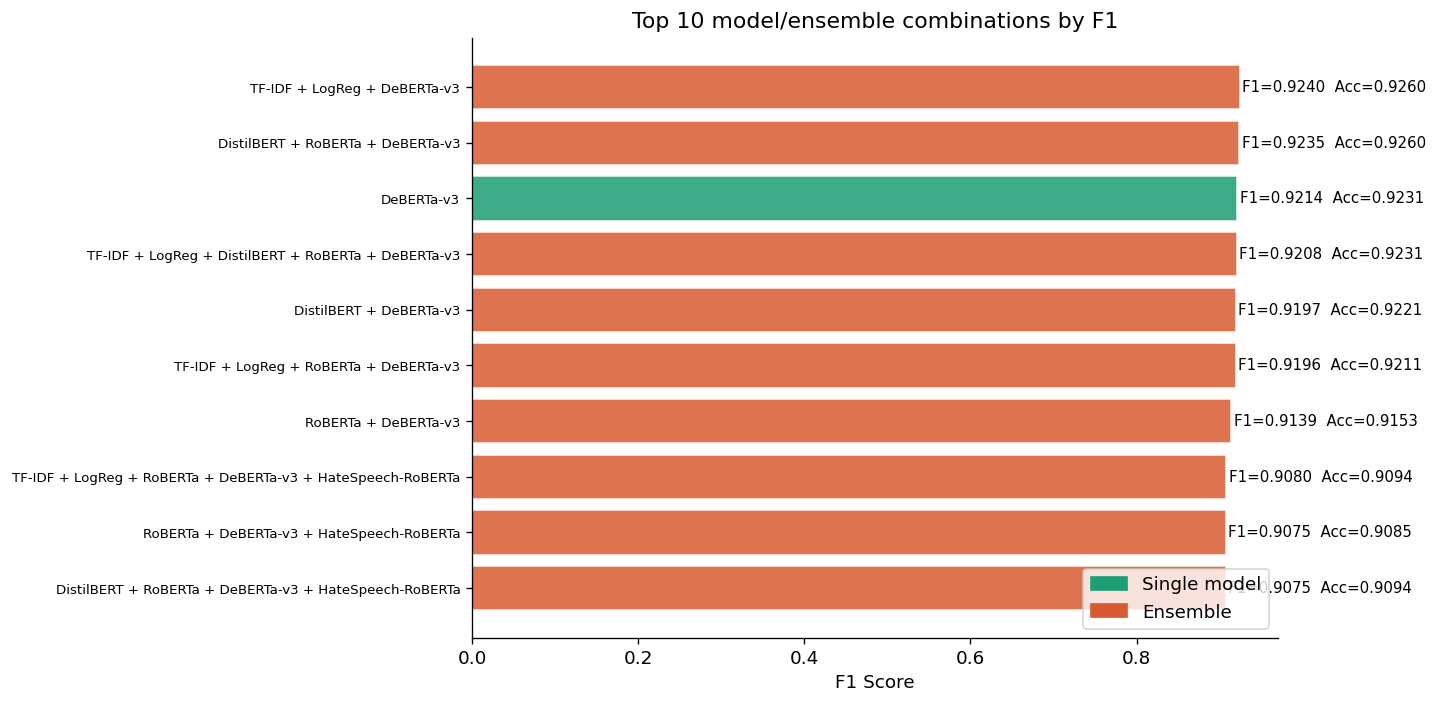


Best combination: TF-IDF + LogReg + DeBERTa-v3
  F1       : 0.9240
  Accuracy : 0.9260
  N models : 2


In [ ]:
top10 = results_df.head(10).copy()

fig, ax = plt.subplots(figsize=(12, 6))

y_pos = np.arange(len(top10))
bars = ax.barh(y_pos, top10['F1'], color=[UNSAFE_COLOR if n > 1 else SAFE_COLOR
               for n in top10['N_models']], edgecolor='white', alpha=0.85)

for i, (f1, acc) in enumerate(zip(top10['F1'], top10['Accuracy'])):
    ax.text(f1 + 0.003, i, f'F1={f1:.4f}  Acc={acc:.4f}', va='center', fontsize=9)

ax.set_yticks(y_pos)
ax.set_yticklabels(top10['Combination'], fontsize=8)
ax.invert_yaxis()
ax.set_xlabel('F1 Score')
ax.set_title('Top 10 model/ensemble combinations by F1')
ax.spines[['top', 'right']].set_visible(False)

# Add legend
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color=SAFE_COLOR, label='Single model'),
    Patch(color=UNSAFE_COLOR, label='Ensemble')
], loc='lower right')

plt.tight_layout()
plt.show()

best_combo = results_df.iloc[0]
print(f'\nBest combination: {best_combo["Combination"]}')
print(f'  F1       : {best_combo["F1"]:.4f}')
print(f'  Accuracy : {best_combo["Accuracy"]:.4f}')
print(f'  N models : {best_combo["N_models"]}')

## 4.4 Weighted ensemble search

Try weighted averaging where better-performing models get higher weights. This can outperform equal-weight averaging when model quality varies significantly.

In [ ]:
# Get the models in the best combination
# Can't split by ' + ' because 'TF-IDF + LogReg' contains ' + '
all_model_names = list(model_probs.keys())
best_combo_str = best_combo['Combination']

# Find which models are in the best combination
best_combo_names = []
remaining = best_combo_str
for name in sorted(all_model_names, key=len, reverse=True):  # longest first to avoid partial matches
    if name in remaining:
        best_combo_names.append(name)
        remaining = remaining.replace(name, '')

print(f'Searching weights for: {best_combo_names}')

if len(best_combo_names) == 1:
    print('Best combination is a single model, skipping weighted search.')
    best_weighted_f1 = best_combo['F1']
    best_weights = [1.0]
else:
    best_weighted_f1 = 0
    best_weights = None
    weighted_results = []

    if len(best_combo_names) <= 4:
        weight_range = np.arange(0.1, 1.0, 0.1)
    else:
        weight_range = np.arange(0.1, 1.0, 0.2)  # coarser grid for 5 models

    def search_weights(combo_names, model_probs, weight_range, y_val):
        """Recursively search weight combinations that sum to ~1.0."""
        n = len(combo_names)
        best_f1 = 0
        best_w = None
        results = []

        def recurse(depth, remaining, current_weights):
            nonlocal best_f1, best_w
            if depth == n - 1:
                w_last = round(remaining, 1)
                if w_last < 0.05:
                    return
                weights = current_weights + [w_last]
                avg = sum(w * model_probs[name] for w, name in zip(weights, combo_names))
                preds = np.argmax(avg, axis=1)
                f1 = f1_score(y_val, preds)
                acc = accuracy_score(y_val, preds)
                result = {f'w{i+1}': w for i, w in enumerate(weights)}
                result['F1'] = f1
                result['Accuracy'] = acc
                results.append(result)
                if f1 > best_f1:
                    best_f1 = f1
                    best_w = weights
                return

            for w in weight_range:
                if w > remaining - 0.05 * (n - depth - 1):
                    break
                recurse(depth + 1, round(remaining - w, 1), current_weights + [round(w, 1)])

        recurse(0, 1.0, [])
        return best_f1, best_w, results

    best_weighted_f1, best_weights, weighted_results = search_weights(
        best_combo_names, model_probs, weight_range, y_val
    )

    wr_df = pd.DataFrame(weighted_results).sort_values('F1', ascending=False)
    print(f'\nTop 5 weight combinations:')
    print(wr_df.head(5).to_string(index=False))

print(f'\nBest weights: {dict(zip(best_combo_names, best_weights))}')
print(f'Best weighted F1: {best_weighted_f1:.4f}')
print(f'Equal weight F1 : {best_combo["F1"]:.4f}')
print(f'Gain from weighting: {best_weighted_f1 - best_combo["F1"]:+.4f}')

Searching weights for: ['TF-IDF + LogReg', 'DeBERTa-v3']

Top 5 weight combinations:
 w1  w2       F1  Accuracy
0.4 0.6 0.924152  0.925998
0.5 0.5 0.924000  0.925998
0.1 0.9 0.923383  0.925024
0.3 0.7 0.922311  0.924051
0.2 0.8 0.922311  0.924051

Best weights: {'TF-IDF + LogReg': np.float64(0.4), 'DeBERTa-v3': np.float64(0.6)}
Best weighted F1: 0.9242
Equal weight F1 : 0.9240
Gain from weighting: +0.0002


---
## 4.5 Prepare eval.csv for prediction

Load eval.csv and apply the same preprocessing pipeline used for the training data: text normalisation and combining movie context with the scenario.

In [ ]:
eval_df = pd.read_csv('eval.csv')
print(f'Eval set: {len(eval_df)} samples')
print(f'Columns: {list(eval_df.columns)}')
print(eval_df.head(3))

# Apply the same preprocessing
eval_df['scenario_clean'] = eval_df['scenario'].fillna('').apply(normalise_text)
eval_df['movie_clean']    = eval_df['movie'].apply(normalise_text)
eval_df['input_text']     = eval_df.apply(build_input_text, axis=1)

eval_texts = eval_df['input_text'].values.tolist()
print(f'\nPreprocessed {len(eval_texts)} eval samples.')
print(f'Sample: {eval_texts[0][:150]}')

Eval set: 712 samples
Columns: ['id', 'movie', 'scenario']
   id            movie                                           scenario
0   0  The Dark Knight  User: "You think you can just waltz in and tak...
1   1  The Dark Knight  Scenario 0: Bruce Wayne responds calmly when t...
2   2  The Dark Knight  Scenario 1: Harvey Dent tells the user that ju...

Preprocessed 712 eval samples.
Sample: [Movie: The Dark Knight] User: "You think you can just waltz in and take Gotham for yourself, huh?" Joker: "Oh, I wouldn't say take, darling. It's mor


## 4.6 Generate predictions on eval.csv

Generate predicted probabilities from each model on the eval set, then combine them using the best ensemble strategy found on the validation set. Each model is loaded one at a time to manage GPU memory.

In [ ]:
def predict_probs(model, texts, tokenizer, max_length, batch_size, device):
    """Generate predicted probabilities for a list of texts."""
    # Create a dummy dataset with label=0 (not used, just for compatibility)
    dummy_labels = [0] * len(texts)

    class PredDataset(Dataset):
        def __init__(self, texts, tokenizer, max_length):
            self.texts = texts
            self.tokenizer = tokenizer
            self.max_length = max_length
        def __len__(self):
            return len(self.texts)
        def __getitem__(self, idx):
            encoding = self.tokenizer(
                self.texts[idx],
                truncation=True,
                padding='max_length',
                max_length=self.max_length,
                return_tensors='pt'
            )
            return {
                'input_ids':      encoding['input_ids'].squeeze(0),
                'attention_mask': encoding['attention_mask'].squeeze(0)
            }

    ds = PredDataset(texts, tokenizer, max_length)
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False)

    model.eval()
    all_logits = []
    with torch.no_grad():
        for batch in loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            all_logits.append(outputs.logits.cpu().numpy())

    logits = np.concatenate(all_logits, axis=0)
    return sp_softmax(logits, axis=1)


PRED_BATCH_SIZE = 16
eval_model_probs = {}

# 1. TF-IDF + LogReg
print('Predicting with TF-IDF + LogReg...')
eval_word = word_tfidf.transform(eval_texts)
eval_char = char_tfidf.transform(eval_texts)
eval_hand = extract_hand_features(eval_texts)
eval_hand_scaled = scaler.transform(eval_hand)
eval_tfidf_full = hstack([eval_word, eval_char, csr_matrix(eval_hand_scaled)])
eval_model_probs['TF-IDF + LogReg'] = lr_model.predict_proba(eval_tfidf_full)
print('  Done.')

# 2. DistilBERT
print('Predicting with DistilBERT...')
m = DistilBertForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)
m.load_state_dict(torch.load('best_distilbert.pt', map_location=device))
m.to(device)
eval_model_probs['DistilBERT'] = predict_probs(m, eval_texts, tokenizer, 256, PRED_BATCH_SIZE, device)
del m; torch.cuda.empty_cache()
print('  Done.')

# 3. RoBERTa
print('Predicting with RoBERTa...')
m = RobertaForSequenceClassification.from_pretrained(ROBERTA_MODEL_NAME, num_labels=2)
m.load_state_dict(torch.load('best_roberta.pt', map_location=device))
m.to(device)
eval_model_probs['RoBERTa'] = predict_probs(m, eval_texts, roberta_tokenizer, 256, PRED_BATCH_SIZE, device)
del m; torch.cuda.empty_cache()
print('  Done.')

# 4. DeBERTa
print('Predicting with DeBERTa...')
m = DebertaV2ForSequenceClassification.from_pretrained(DEBERTA_MODEL_NAME, num_labels=2)
m = m.float()
m.load_state_dict(torch.load('best_deberta.pt', map_location=device))
m.to(device)
eval_model_probs['DeBERTa-v3'] = predict_probs(m, eval_texts, deberta_tokenizer, 256, PRED_BATCH_SIZE, device)
del m; torch.cuda.empty_cache()
print('  Done.')

# 5. HateSpeech-RoBERTa
print('Predicting with HateSpeech-RoBERTa...')
m = AutoModelForSequenceClassification.from_pretrained(
    HATE_MODEL_NAME, num_labels=2, ignore_mismatched_sizes=True
)
m.load_state_dict(torch.load('best_hatespeech_roberta.pt', map_location=device))
m.to(device)
eval_model_probs['HateSpeech-RoBERTa'] = predict_probs(m, eval_texts, hate_tokenizer, 256, PRED_BATCH_SIZE, device)
del m; torch.cuda.empty_cache()
print('  Done.')

print(f'\nAll eval predictions collected for {len(eval_model_probs)} models.')

Predicting with TF-IDF + LogReg...
  Done.
Predicting with DistilBERT...


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Done.
Predicting with RoBERTa...


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

[transformers] DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     | 
----------------------------------------+------------+-
mask_predictions.dense.bias             | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
classifier.bias                         | MISSING    | 
pooler.dense.weight                     | MISSING    | 
classifier.weight                       | MISSING    | 
pooler.den

  Done.
Predicting with HateSpeech-RoBERTa...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

  Done.

All eval predictions collected for 5 models.


## 4.7 Apply the best ensemble to eval.csv

Combine eval predictions using the best ensemble strategy (combination and weights) found on the validation set.

In [ ]:
# Apply best ensemble
print(f'Using ensemble: {best_combo_names}')
print(f'Weights: {dict(zip(best_combo_names, best_weights))}')

eval_ensemble_probs = np.zeros_like(eval_model_probs[best_combo_names[0]])
for name, weight in zip(best_combo_names, best_weights):
    eval_ensemble_probs += weight * eval_model_probs[name]

eval_preds = np.argmax(eval_ensemble_probs, axis=1)

print(f'\nEval predictions generated: {len(eval_preds)} samples')
print(f'  Predicted safe (0)  : {(eval_preds == 0).sum()} ({(eval_preds == 0).mean()*100:.1f}%)')
print(f'  Predicted unsafe (1): {(eval_preds == 1).sum()} ({(eval_preds == 1).mean()*100:.1f}%)')

Using ensemble: ['TF-IDF + LogReg', 'DeBERTa-v3']
Weights: {'TF-IDF + LogReg': np.float64(0.4), 'DeBERTa-v3': np.float64(0.6)}

Eval predictions generated: 712 samples
  Predicted safe (0)  : 419 (58.8%)
  Predicted unsafe (1): 293 (41.2%)


## 4.8 Generate Kaggle submission file

Create the submission CSV in the exact format required: two columns (id, label) with 712 rows matching eval.csv.

In [ ]:
import os
from datetime import datetime

submission = pd.DataFrame({
    'id': eval_df['id'],
    'label': eval_preds
})

# Verify format matches submission_sample.csv
print(f'Submission shape: {submission.shape}')
print(f'Columns: {list(submission.columns)}')
print(f'Label dtype: {submission["label"].dtype}')
print(f'\nFirst 5 rows:')
print(submission.head())
print(f'\nLast 5 rows:')
print(submission.tail())

# Save locally
submission.to_csv('submission.csv', index=False)
print(f'\nSaved: submission.csv ({len(submission)} rows)')

# Save to Google Drive with date + index + modelname + f1_score
try:
    drive_folder = '/content/drive/MyDrive/SMU_MITB_NLP/Assignment/Submission'
    os.makedirs(drive_folder, exist_ok=True)

    today = datetime.now().strftime('%Y%m%d')

    # Build model name from the ensemble combination
    combo_tag = best_combo['Combination'].lower().replace(' ', '_').replace('-', '_').replace('+', '').replace('__', '_').strip('_')
    score = f'{best_weighted_f1:.4f}'

    # Find the next number for today
    existing = [f for f in os.listdir(drive_folder) if f.startswith(today)]
    next_num = len(existing) + 1

    filename = f'{today}_{next_num:02d}_ensemble_{combo_tag}_F1_{score}.csv'
    filepath = os.path.join(drive_folder, filename)

    submission.to_csv(filepath, index=False)
    print(f'Saved to Google Drive: {filepath}')
except Exception as e:
    print(f'Google Drive save failed: {e}')

Submission shape: (712, 2)
Columns: ['id', 'label']
Label dtype: int64

First 5 rows:
   id  label
0   0      1
1   1      0
2   2      0
3   3      1
4   4      1

Last 5 rows:
      id  label
707  707      0
708  708      1
709  709      0
710  710      1
711  711      0

Saved: submission.csv (712 rows)
Saved to Google Drive: /content/drive/MyDrive/SMU_MITB_NLP/Assignment/Submission/20260611_02_ensemble_tf_idf_logreg_deberta_v3_F1_0.9242.csv


## 4.9 Generate individual model submissions (backup)

Also generate submission files for each individual model, in case the ensemble does not perform best on the Kaggle leaderboard. You can submit up to 10 per day, so it is worth trying different options.

In [ ]:
backup_folder = '/content/drive/MyDrive/SMU_MITB_NLP/Assignment/Submission/Backup'
os.makedirs(backup_folder, exist_ok=True)

today = datetime.now().strftime('%Y%m%d')
existing = [f for f in os.listdir(backup_folder) if f.startswith(today)]
start_num = len(existing) + 1

for idx, (name, probs) in enumerate(eval_model_probs.items()):
    preds = np.argmax(probs, axis=1)
    sub = pd.DataFrame({'id': eval_df['id'], 'label': preds})

    # Calculate F1 on validation set for the filename
    val_preds = np.argmax(model_probs[name], axis=1)
    model_f1 = f1_score(y_val, val_preds)

    model_tag = name.lower().replace(' ', '_').replace('-', '_').replace('+', '').replace('__', '_').strip('_')
    filename = f'{today}_{start_num + idx:02d}_{model_tag}_F1_{model_f1:.4f}.csv'
    filepath = os.path.join(backup_folder, filename)

    sub.to_csv(filepath, index=False)
    safe_pct = (preds == 0).mean() * 100
    print(f'  {filename:60s} | safe: {safe_pct:.1f}% | unsafe: {100-safe_pct:.1f}%')

print(f'\nTotal backup files saved: {len(eval_model_probs)}')
print(f'Location: {backup_folder}')

  20260611_01_tf_idf_logreg_F1_0.7830.csv                      | safe: 55.3% | unsafe: 44.7%
  20260611_02_distilbert_F1_0.8556.csv                         | safe: 63.1% | unsafe: 36.9%
  20260611_03_roberta_F1_0.8911.csv                            | safe: 57.4% | unsafe: 42.6%
  20260611_04_deberta_v3_F1_0.9214.csv                         | safe: 58.7% | unsafe: 41.3%
  20260611_05_hatespeech_roberta_F1_0.8611.csv                 | safe: 56.7% | unsafe: 43.3%

Total backup files saved: 5
Location: /content/drive/MyDrive/SMU_MITB_NLP/Assignment/Submission/Backup


## 4.10 Final summary

In [ ]:
print('=' * 60)
print('STEP 5 FINAL SUMMARY')
print('=' * 60)
print(f'Ensemble strategy     : Soft voting (weighted probability averaging)')
print(f'Best combination      : {best_combo["Combination"]}')
print(f'Best weights          : {dict(zip(best_combo_names, best_weights))}')
print(f'Val F1 (equal weight) : {best_combo["F1"]:.4f}')
print(f'Val F1 (best weight)  : {best_weighted_f1:.4f}')
print(f'')
print(f'Eval predictions:')
print(f'  Total samples       : {len(eval_preds)}')
print(f'  Predicted safe      : {(eval_preds==0).sum()}')
print(f'  Predicted unsafe    : {(eval_preds==1).sum()}')
print(f'')
print(f'Submission files generated:')
print(f'  submission.csv (best ensemble)')
for name in eval_model_probs:
    filename = f'submission_{name.lower().replace("-", "_").replace(" ", "_")}.csv'
    print(f'  {filename}')
print('=' * 60)

STEP 5 FINAL SUMMARY
Ensemble strategy     : Soft voting (weighted probability averaging)
Best combination      : TF-IDF + LogReg + DeBERTa-v3
Best weights          : {'TF-IDF + LogReg': np.float64(0.4), 'DeBERTa-v3': np.float64(0.6)}
Val F1 (equal weight) : 0.9240
Val F1 (best weight)  : 0.9242

Eval predictions:
  Total samples       : 712
  Predicted safe      : 419
  Predicted unsafe    : 293

Submission files generated:
  submission.csv (best ensemble)
  submission_tf_idf_+_logreg.csv
  submission_distilbert.csv
  submission_roberta.csv
  submission_deberta_v3.csv
  submission_hatespeech_roberta.csv


---
# Step 5: K-Fold DeBERTa Ensemble

Instead of relying on a single model, we train 5 DeBERTa models using stratified k-fold cross-validation on the **full cleaned dataset** (no holdout). Each fold model sees different training data, so they make different errors. Averaging their predictions on eval.csv produces a more robust and stable result than any single model. This approach also uses 100% of the cleaned training data, giving each model more to learn from.

## 5.1 Setup

Define the k-fold configuration. We use the full cleaned dataset (`df_clean`) rather than the train/val split, since we want every sample to contribute to training.

In [ ]:
import os
from sklearn.model_selection import StratifiedKFold
from scipy.special import softmax as sp_softmax
from transformers import DebertaV2Tokenizer, DebertaV2ForSequenceClassification

# Full cleaned dataset
all_texts  = df_clean['input_text'].values
all_labels = df_clean['label'].values

# K-fold config
N_FOLDS       = 5
KFOLD_EPOCHS  = 3        # epoch 3 was the sweet spot for DeBERTa
KFOLD_LR      = 1e-5
KFOLD_BS      = 8        # batch size (use 8 for T4, 16 for A100)
ACCUM_STEPS   = 2        # gradient accumulation (effective batch = 16)
KFOLD_MAXLEN  = 256
DEBERTA_NAME  = 'microsoft/deberta-v3-base'

kfold_tokenizer = DebertaV2Tokenizer.from_pretrained(DEBERTA_NAME)

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_SEED)

# Create folder for fold checkpoints
os.makedirs('fold_checkpoints', exist_ok=True)

print(f'Full dataset       : {len(all_texts):,} samples')
print(f'Folds              : {N_FOLDS}')
print(f'Epochs per fold    : {KFOLD_EPOCHS}')
print(f'Batch size         : {KFOLD_BS} (effective: {KFOLD_BS * ACCUM_STEPS})')
print(f'Learning rate      : {KFOLD_LR}')

tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

Full dataset       : 6,407 samples
Folds              : 5
Epochs per fold    : 3
Batch size         : 8 (effective: 16)
Learning rate      : 1e-05


## 5.2 Dataset class

Define the dataset class for k-fold training. This is the same structure used throughout the notebook.

In [ ]:
class KFoldDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt'
        )
        return {
            'input_ids':      encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'labels':         torch.tensor(self.labels[idx], dtype=torch.long)
        }


class KFoldPredDataset(Dataset):
    """Dataset for prediction only (no labels needed)."""
    def __init__(self, texts, tokenizer, max_length):
        self.texts = texts
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt'
        )
        return {
            'input_ids':      encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0)
        }

print('Dataset classes defined.')

Dataset classes defined.


## 5.3 Train k-fold models

Train one DeBERTa model per fold. Each model trains on 80% of the data and validates on the remaining 20%. The best checkpoint for each fold (by validation F1) is saved. Out-of-fold predictions are also collected to measure overall cross-validation performance.

In [ ]:
oof_probs = np.zeros((len(all_texts), 2), dtype=np.float32)
fold_results = []

for fold_idx, (train_idx, val_idx) in enumerate(skf.split(all_texts, all_labels)):
    print(f'\n{"=" * 60}')
    print(f'FOLD {fold_idx + 1}/{N_FOLDS}')
    print(f'{"=" * 60}')
    fold_start = time.time()

    # Split data
    fold_train_texts  = all_texts[train_idx].tolist()
    fold_train_labels = all_labels[train_idx].tolist()
    fold_val_texts    = all_texts[val_idx].tolist()
    fold_val_labels   = all_labels[val_idx].tolist()

    # Create dataloaders
    fold_train_ds = KFoldDataset(fold_train_texts, fold_train_labels, kfold_tokenizer, KFOLD_MAXLEN)
    fold_val_ds   = KFoldDataset(fold_val_texts,   fold_val_labels,   kfold_tokenizer, KFOLD_MAXLEN)

    fold_train_loader = DataLoader(fold_train_ds, batch_size=KFOLD_BS, shuffle=True)
    fold_val_loader   = DataLoader(fold_val_ds,   batch_size=KFOLD_BS, shuffle=False)

    print(f'  Train: {len(fold_train_texts)} samples, Val: {len(fold_val_texts)} samples')

    # Fresh model
    fold_model = DebertaV2ForSequenceClassification.from_pretrained(DEBERTA_NAME, num_labels=2)
    fold_model = fold_model.float()
    fold_model.to(device)

    fold_optimizer = torch.optim.AdamW(
        fold_model.parameters(), lr=KFOLD_LR, weight_decay=0.01, eps=1e-6
    )
    fold_total_steps = len(fold_train_loader) * KFOLD_EPOCHS
    fold_scheduler = get_linear_schedule_with_warmup(
        fold_optimizer,
        num_warmup_steps=int(fold_total_steps * 0.1),
        num_training_steps=fold_total_steps
    )

    # Train with best checkpoint tracking
    fold_best_f1 = 0
    checkpoint_path = f'fold_checkpoints/deberta_fold{fold_idx+1}.pt'

    for epoch in range(KFOLD_EPOCHS):
        fold_model.train()
        fold_optimizer.zero_grad()
        epoch_loss = 0
        log_interval = 50  # print every 50 steps

        for step, batch in enumerate(fold_train_loader):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = fold_model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            loss = outputs.loss / ACCUM_STEPS
            loss.backward()
            epoch_loss += outputs.loss.item()

            if (step + 1) % ACCUM_STEPS == 0:
                torch.nn.utils.clip_grad_norm_(fold_model.parameters(), max_norm=1.0)
                fold_optimizer.step()
                fold_scheduler.step()
                fold_optimizer.zero_grad()

            if (step + 1) % log_interval == 0:
                avg_loss_so_far = epoch_loss / (step + 1)
                lr_now = fold_scheduler.get_last_lr()[0]
                print(f'    Step {step+1}/{len(fold_train_loader)} | '
                      f'Loss: {outputs.loss.item():.4f} | '
                      f'Avg Loss: {avg_loss_so_far:.4f} | '
                      f'LR: {lr_now:.2e}')

        # Validate
        fold_model.eval()
        val_preds_list, val_labels_list = [], []
        val_loss = 0
        with torch.no_grad():
            for batch in fold_val_loader:
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels_batch = batch['labels'].to(device)
                outputs = fold_model(input_ids=input_ids, attention_mask=attention_mask, labels=labels_batch)
                val_loss += outputs.loss.item()
                preds = torch.argmax(outputs.logits, dim=1)
                val_preds_list.extend(preds.cpu().numpy())
                val_labels_list.extend(labels_batch.cpu().numpy())

        epoch_acc = accuracy_score(val_labels_list, val_preds_list)
        epoch_f1  = f1_score(val_labels_list, val_preds_list)
        avg_train_loss = epoch_loss / len(fold_train_loader)
        avg_val_loss   = val_loss / len(fold_val_loader)

        status = ''
        if epoch_f1 > fold_best_f1:
            fold_best_f1 = epoch_f1
            torch.save(fold_model.state_dict(), checkpoint_path)
            status = ' << saved'

        print(f'  Epoch {epoch+1}/{KFOLD_EPOCHS} | '
              f'Train Loss: {avg_train_loss:.4f} | '
              f'Val Loss: {avg_val_loss:.4f} | '
              f'Acc: {epoch_acc:.4f} | '
              f'F1: {epoch_f1:.4f}{status}')

    # Load best checkpoint and get OOF probabilities
    fold_model.load_state_dict(torch.load(checkpoint_path, map_location=device))
    fold_model.eval()
    fold_logits = []
    with torch.no_grad():
        for batch in fold_val_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            outputs = fold_model(input_ids=input_ids, attention_mask=attention_mask)
            fold_logits.append(outputs.logits.cpu().numpy())

    fold_logits = np.concatenate(fold_logits, axis=0)
    fold_probs  = sp_softmax(fold_logits, axis=1)
    oof_probs[val_idx] = fold_probs

    fold_preds = np.argmax(fold_probs, axis=1)
    fold_acc = accuracy_score(fold_val_labels, fold_preds)
    fold_f1  = f1_score(fold_val_labels, fold_preds)

    elapsed = time.time() - fold_start
    fold_results.append({'fold': fold_idx+1, 'accuracy': fold_acc, 'f1': fold_f1, 'time_min': elapsed/60})
    print(f'\n  Fold {fold_idx+1} best: Acc={fold_acc:.4f}, F1={fold_f1:.4f} ({elapsed/60:.1f} min)')

    # Free memory
    del fold_model
    torch.cuda.empty_cache()

# Overall OOF performance
oof_preds = np.argmax(oof_probs, axis=1)
oof_acc = accuracy_score(all_labels, oof_preds)
oof_f1  = f1_score(all_labels, oof_preds)

print(f'\n{"=" * 60}')
print(f'K-FOLD CROSS-VALIDATION RESULTS')
print(f'{"=" * 60}')
fold_df = pd.DataFrame(fold_results)
print(fold_df.to_string(index=False))
print(f'\nOverall OOF: Accuracy={oof_acc:.4f}, F1={oof_f1:.4f}')
print(f'Mean fold F1: {fold_df["f1"].mean():.4f} (+/- {fold_df["f1"].std():.4f})')
print(f'Total time: {fold_df["time_min"].sum():.1f} min')


FOLD 1/5
  Train: 5125 samples, Val: 1282 samples


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

[transformers] DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     | 
----------------------------------------+------------+-
mask_predictions.dense.weight           | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
classifier.bias                         | MISSING    | 
classifier.weight                       | MISSING    | 
pooler.dense.bias                       | MISSING    | 
pooler.den

    Step 50/641 | Loss: 0.6780 | Avg Loss: 0.6913 | LR: 1.30e-06
    Step 100/641 | Loss: 0.7362 | Avg Loss: 0.6899 | LR: 2.60e-06
    Step 150/641 | Loss: 0.7030 | Avg Loss: 0.6897 | LR: 3.91e-06
    Step 200/641 | Loss: 0.7820 | Avg Loss: 0.6897 | LR: 5.21e-06
    Step 250/641 | Loss: 0.6766 | Avg Loss: 0.6865 | LR: 6.51e-06
    Step 300/641 | Loss: 0.5470 | Avg Loss: 0.6824 | LR: 7.81e-06
    Step 350/641 | Loss: 0.4701 | Avg Loss: 0.6751 | LR: 9.11e-06
    Step 400/641 | Loss: 0.5225 | Avg Loss: 0.6649 | LR: 9.95e-06
    Step 450/641 | Loss: 0.4033 | Avg Loss: 0.6510 | LR: 9.81e-06
    Step 500/641 | Loss: 0.6068 | Avg Loss: 0.6310 | LR: 9.66e-06
    Step 550/641 | Loss: 0.5415 | Avg Loss: 0.6072 | LR: 9.52e-06
    Step 600/641 | Loss: 0.5650 | Avg Loss: 0.5903 | LR: 9.38e-06
  Epoch 1/3 | Train Loss: 0.5743 | Val Loss: 0.2915 | Acc: 0.8674 | F1: 0.8844 << saved
    Step 50/641 | Loss: 0.0670 | Avg Loss: 0.2441 | LR: 9.12e-06
    Step 100/641 | Loss: 0.3173 | Avg Loss: 0.3009 | LR:

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

...

[transformers] DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     | 
----------------------------------------+------------+-
mask_predictions.dense.weight           | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
classifier.bias                         | MISSING    | 
classifier.weight                       | MISSING    | 
pooler.dense.bias                       | MISSING    | 
pooler.den

    Step 50/641 | Loss: 0.6648 | Avg Loss: 0.6979 | LR: 1.30e-06
    Step 100/641 | Loss: 0.7067 | Avg Loss: 0.6988 | LR: 2.60e-06
    Step 150/641 | Loss: 0.6770 | Avg Loss: 0.6967 | LR: 3.91e-06
    Step 200/641 | Loss: 0.7175 | Avg Loss: 0.6953 | LR: 5.21e-06
    Step 250/641 | Loss: 0.6857 | Avg Loss: 0.6934 | LR: 6.51e-06
    Step 300/641 | Loss: 0.6619 | Avg Loss: 0.6928 | LR: 7.81e-06
    Step 350/641 | Loss: 0.4717 | Avg Loss: 0.6852 | LR: 9.11e-06
    Step 400/641 | Loss: 0.6611 | Avg Loss: 0.6617 | LR: 9.95e-06
    Step 450/641 | Loss: 0.5175 | Avg Loss: 0.6350 | LR: 9.81e-06
    Step 500/641 | Loss: 0.4175 | Avg Loss: 0.6056 | LR: 9.66e-06
    Step 550/641 | Loss: 0.0802 | Avg Loss: 0.5886 | LR: 9.52e-06
    Step 600/641 | Loss: 0.5700 | Avg Loss: 0.5735 | LR: 9.38e-06
  Epoch 1/3 | Train Loss: 0.5553 | Val Loss: 0.3054 | Acc: 0.8743 | F1: 0.8857 << saved
    Step 50/641 | Loss: 0.0413 | Avg Loss: 0.2450 | LR: 9.12e-06
    Step 100/641 | Loss: 0.5265 | Avg Loss: 0.2455 | LR:

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

[transformers] DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     | 
----------------------------------------+------------+-
mask_predictions.dense.weight           | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
classifier.bias                         | MISSING    | 
classifier.weight                       | MISSING    | 
pooler.dense.bias                       | MISSING    | 
pooler.den

    Step 50/641 | Loss: 0.7364 | Avg Loss: 0.6983 | LR: 1.30e-06
    Step 100/641 | Loss: 0.6791 | Avg Loss: 0.6984 | LR: 2.60e-06
    Step 150/641 | Loss: 0.6826 | Avg Loss: 0.6961 | LR: 3.91e-06
    Step 200/641 | Loss: 0.6801 | Avg Loss: 0.6950 | LR: 5.21e-06
    Step 250/641 | Loss: 0.5940 | Avg Loss: 0.6900 | LR: 6.51e-06
    Step 300/641 | Loss: 0.5350 | Avg Loss: 0.6826 | LR: 7.81e-06
    Step 350/641 | Loss: 0.5837 | Avg Loss: 0.6745 | LR: 9.11e-06
    Step 400/641 | Loss: 0.5213 | Avg Loss: 0.6604 | LR: 9.95e-06
    Step 450/641 | Loss: 0.5066 | Avg Loss: 0.6442 | LR: 9.81e-06
    Step 500/641 | Loss: 0.6371 | Avg Loss: 0.6215 | LR: 9.66e-06
    Step 550/641 | Loss: 0.3074 | Avg Loss: 0.6027 | LR: 9.52e-06
    Step 600/641 | Loss: 0.8019 | Avg Loss: 0.5816 | LR: 9.38e-06
  Epoch 1/3 | Train Loss: 0.5678 | Val Loss: 0.3172 | Acc: 0.8681 | F1: 0.8822 << saved
    Step 50/641 | Loss: 0.2334 | Avg Loss: 0.3099 | LR: 9.12e-06
    Step 100/641 | Loss: 1.0316 | Avg Loss: 0.3086 | LR:

## 5.4 Save fold checkpoints to Google Drive

Save all fold checkpoints to Google Drive so they can be reused in a new session without retraining.

In [ ]:
import shutil

drive_ckpt_folder = '/content/drive/MyDrive/SMU_MITB_NLP/Assignment/fold_checkpoints/kfold'
os.makedirs(drive_ckpt_folder, exist_ok=True)

for fold_idx in range(N_FOLDS):
    src = f'fold_checkpoints/deberta_fold{fold_idx+1}.pt'
    dst = f'{drive_ckpt_folder}/deberta_fold{fold_idx+1}.pt'
    if os.path.exists(src):
        shutil.copy(src, dst)
        print(f'Saved: {dst}')

print('All fold checkpoints saved to Google Drive.')

Saved: /content/drive/MyDrive/SMU_MITB_NLP/Assignment/fold_checkpoints/kfold/deberta_fold1.pt
Saved: /content/drive/MyDrive/SMU_MITB_NLP/Assignment/fold_checkpoints/kfold/deberta_fold2.pt
Saved: /content/drive/MyDrive/SMU_MITB_NLP/Assignment/fold_checkpoints/kfold/deberta_fold3.pt
Saved: /content/drive/MyDrive/SMU_MITB_NLP/Assignment/fold_checkpoints/kfold/deberta_fold4.pt
Saved: /content/drive/MyDrive/SMU_MITB_NLP/Assignment/fold_checkpoints/kfold/deberta_fold5.pt
All fold checkpoints saved to Google Drive.


## 5.5 Threshold tuning

Instead of using the default 0.5 threshold, search for the optimal decision threshold using the out-of-fold predictions. This can squeeze an extra 0.5 to 1 point of F1.

Best threshold: 0.55
  F1 at best threshold : 0.9103
  F1 at default (0.50) : 0.9094
  Gain from tuning     : +0.0009


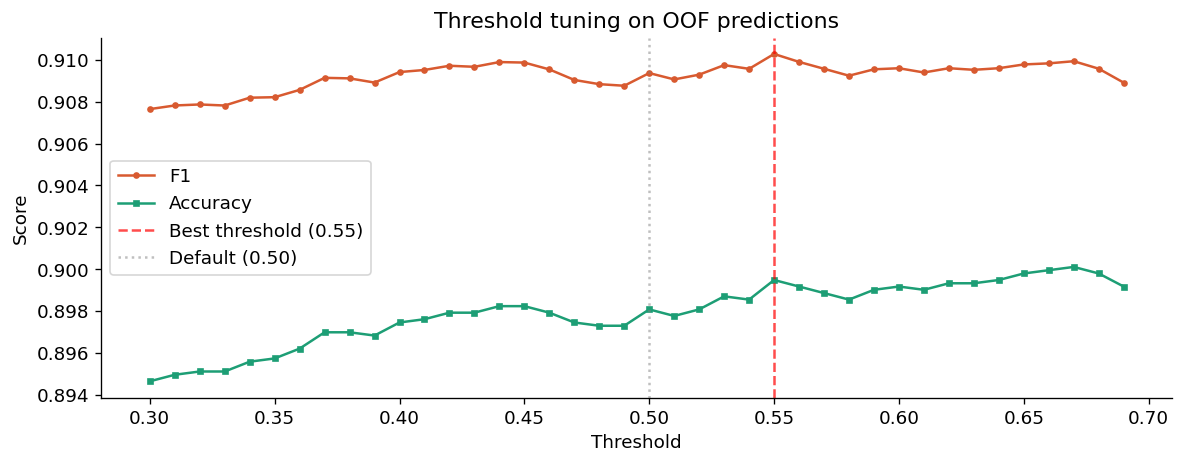

In [ ]:
thresholds = np.arange(0.30, 0.70, 0.01)
threshold_results = []

for t in thresholds:
    preds = (oof_probs[:, 1] > t).astype(int)
    f1 = f1_score(all_labels, preds)
    acc = accuracy_score(all_labels, preds)
    threshold_results.append({'threshold': round(t, 2), 'f1': f1, 'accuracy': acc})

thresh_df = pd.DataFrame(threshold_results)
best_thresh_row = thresh_df.loc[thresh_df['f1'].idxmax()]
best_threshold = best_thresh_row['threshold']

print(f'Best threshold: {best_threshold:.2f}')
print(f'  F1 at best threshold : {best_thresh_row["f1"]:.4f}')
print(f'  F1 at default (0.50) : {thresh_df[thresh_df["threshold"]==0.50]["f1"].values[0]:.4f}')
print(f'  Gain from tuning     : {best_thresh_row["f1"] - thresh_df[thresh_df["threshold"]==0.50]["f1"].values[0]:+.4f}')

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(thresh_df['threshold'], thresh_df['f1'], 'o-', color=UNSAFE_COLOR, label='F1', markersize=3)
ax.plot(thresh_df['threshold'], thresh_df['accuracy'], 's-', color=SAFE_COLOR, label='Accuracy', markersize=3)
ax.axvline(x=best_threshold, color='red', linestyle='--', alpha=0.7, label=f'Best threshold ({best_threshold:.2f})')
ax.axvline(x=0.50, color='gray', linestyle=':', alpha=0.5, label='Default (0.50)')
ax.set_xlabel('Threshold')
ax.set_ylabel('Score')
ax.set_title('Threshold tuning on OOF predictions')
ax.legend()
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

## 5.6 Generate eval.csv predictions with k-fold ensemble

Load each fold checkpoint, predict on eval.csv, and average the probabilities across all folds. Then apply the optimised threshold to get the final predictions.

In [ ]:
# Make sure eval_texts is available (from section 4.5)

# Download eval.csv from Account 1's shared link
gdown.download('https://drive.google.com/uc?id=1plPkEalcqgs8T5P-b2cSBjiyrfymNroC', 'eval.csv', quiet=False)

# If not, uncomment and run:
eval_df = pd.read_csv('eval.csv')
eval_df['scenario_clean'] = eval_df['scenario'].fillna('').apply(normalise_text)
eval_df['movie_clean']    = eval_df['movie'].apply(normalise_text)
eval_df['input_text']     = eval_df.apply(build_input_text, axis=1)
eval_texts = eval_df['input_text'].values.tolist()


eval_pred_ds = KFoldPredDataset(eval_texts, kfold_tokenizer, KFOLD_MAXLEN)
eval_pred_loader = DataLoader(eval_pred_ds, batch_size=16, shuffle=False)

# Accumulate probabilities from all folds
eval_ensemble_probs = np.zeros((len(eval_texts), 2), dtype=np.float32)

for fold_idx in range(N_FOLDS):
    print(f'Predicting with fold {fold_idx+1}/{N_FOLDS}...')

    # Try local checkpoint first, then Google Drive
    ckpt_path = f'fold_checkpoints/deberta_fold{fold_idx+1}.pt'
    if not os.path.exists(ckpt_path):
        ckpt_path = f'/content/drive/MyDrive/SMU_MITB_NLP/Assignment/fold_checkpoints/kfold/deberta_fold{fold_idx+1}.pt'

    fold_model = DebertaV2ForSequenceClassification.from_pretrained(DEBERTA_NAME, num_labels=2)
    fold_model = fold_model.float()
    fold_model.load_state_dict(torch.load(ckpt_path, map_location=device))
    fold_model.to(device)
    fold_model.eval()

    fold_logits = []
    with torch.no_grad():
        for batch in eval_pred_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            outputs = fold_model(input_ids=input_ids, attention_mask=attention_mask)
            fold_logits.append(outputs.logits.cpu().numpy())

    fold_logits = np.concatenate(fold_logits, axis=0)
    eval_ensemble_probs += sp_softmax(fold_logits, axis=1)

    del fold_model
    torch.cuda.empty_cache()
    print(f'  Fold {fold_idx+1} done.')

# Average across folds
eval_ensemble_probs /= N_FOLDS

# Apply both default and tuned threshold
eval_preds_default = np.argmax(eval_ensemble_probs, axis=1)
eval_preds_tuned   = (eval_ensemble_probs[:, 1] > best_threshold).astype(int)

print(f'\nPredictions with default threshold (0.50):')
print(f'  Safe: {(eval_preds_default==0).sum()}, Unsafe: {(eval_preds_default==1).sum()}')

print(f'\nPredictions with tuned threshold ({best_threshold:.2f}):')
print(f'  Safe: {(eval_preds_tuned==0).sum()}, Unsafe: {(eval_preds_tuned==1).sum()}')

Downloading...
From: https://drive.google.com/uc?id=1plPkEalcqgs8T5P-b2cSBjiyrfymNroC
To: /content/eval.csv
100%|██████████| 161k/161k [00:00<00:00, 33.5MB/s]


Predicting with fold 1/5...


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

[transformers] DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     | 
----------------------------------------+------------+-
mask_predictions.dense.weight           | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
classifier.bias                         | MISSING    | 
classifier.weight                       | MISSING    | 
pooler.dense.bias                       | MISSING    | 
pooler.den

  Fold 1 done.
Predicting with fold 2/5...


...

[transformers] DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     | 
----------------------------------------+------------+-
mask_predictions.dense.weight           | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
classifier.bias                         | MISSING    | 
classifier.weight                       | MISSING    | 
pooler.dense.bias                       | MISSING    | 
pooler.den

  Fold 4 done.
Predicting with fold 5/5...


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

[transformers] DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     | 
----------------------------------------+------------+-
mask_predictions.dense.weight           | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
classifier.bias                         | MISSING    | 
classifier.weight                       | MISSING    | 
pooler.dense.bias                       | MISSING    | 
pooler.den

  Fold 5 done.

Predictions with default threshold (0.50):
  Safe: 378, Unsafe: 334

Predictions with tuned threshold (0.55):
  Safe: 381, Unsafe: 331


## 5.7 Generate Kaggle submission files

Generate two submission files: one with the default threshold and one with the tuned threshold. Submit both to Kaggle and see which scores higher.

In [ ]:
from datetime import datetime

oof_preds = np.argmax(oof_probs, axis=1)
oof_f1 = f1_score(all_labels, oof_preds)

drive_folder = '/content/drive/MyDrive/SMU_MITB_NLP/Assignment/Submission'
os.makedirs(drive_folder, exist_ok=True)

today = datetime.now().strftime('%Y%m%d')
existing = [f for f in os.listdir(drive_folder) if f.startswith(today)]
next_num = len(existing) + 1

# === Threshold sweep: generate submissions for 0.50 to 0.60 ===
sweep_thresholds = np.arange(0.50, 0.61, 0.01)
sweep_results = []

for i, t in enumerate(sweep_thresholds):
    t = round(t, 2)

    # Predictions using this threshold
    preds = (eval_ensemble_probs[:, 1] > t).astype(int)

    # OOF F1 at this threshold (to put in filename)
    oof_preds_t = (oof_probs[:, 1] > t).astype(int)
    oof_f1_t = f1_score(all_labels, oof_preds_t)

    # Save
    sub = pd.DataFrame({'id': eval_df['id'], 'label': preds})
    fname = f'{today}_{next_num + i:02d}_kfold_deberta_thresh{t:.2f}_OOF_F1_{oof_f1_t:.4f}.csv'
    sub.to_csv(os.path.join(drive_folder, fname), index=False)
    sub.to_csv(f'submission_thresh_{t:.2f}.csv', index=False)

    n_unsafe = preds.sum()
    sweep_results.append({
        'threshold': t, 'oof_f1': oof_f1_t,
        'unsafe': n_unsafe, 'safe': len(preds) - n_unsafe,
        'filename': fname
    })
    print(f'  t={t:.2f} | OOF F1={oof_f1_t:.4f} | unsafe={n_unsafe} | {fname}')

# Show summary table
sweep_df = pd.DataFrame(sweep_results)
print(f'\n{"=" * 60}')
print('THRESHOLD SWEEP SUMMARY')
print(f'{"=" * 60}')
print(sweep_df.to_string(index=False))
print(f'\nBest OOF threshold: {sweep_df.loc[sweep_df["oof_f1"].idxmax(), "threshold"]:.2f}')
print(f'\nSubmit the top 2-3 to Kaggle:')
top3 = sweep_df.nlargest(3, 'oof_f1')
for _, row in top3.iterrows():
    print(f'  → {row["filename"]}')

  t=0.50 | OOF F1=0.9094 | unsafe=334 | 20260612_03_kfold_deberta_thresh0.50_OOF_F1_0.9094.csv
  t=0.51 | OOF F1=0.9091 | unsafe=332 | 20260612_04_kfold_deberta_thresh0.51_OOF_F1_0.9091.csv
  t=0.52 | OOF F1=0.9093 | unsafe=332 | 20260612_05_kfold_deberta_thresh0.52_OOF_F1_0.9093.csv
  t=0.53 | OOF F1=0.9097 | unsafe=331 | 20260612_06_kfold_deberta_thresh0.53_OOF_F1_0.9097.csv
  t=0.54 | OOF F1=0.9096 | unsafe=331 | 20260612_07_kfold_deberta_thresh0.54_OOF_F1_0.9096.csv
  t=0.55 | OOF F1=0.9103 | unsafe=331 | 20260612_08_kfold_deberta_thresh0.55_OOF_F1_0.9103.csv
  t=0.56 | OOF F1=0.9099 | unsafe=330 | 20260612_09_kfold_deberta_thresh0.56_OOF_F1_0.9099.csv
  t=0.57 | OOF F1=0.9096 | unsafe=329 | 20260612_10_kfold_deberta_thresh0.57_OOF_F1_0.9096.csv
  t=0.58 | OOF F1=0.9092 | unsafe=327 | 20260612_11_kfold_deberta_thresh0.58_OOF_F1_0.9092.csv
  t=0.59 | OOF F1=0.9095 | unsafe=327 | 20260612_12_kfold_deberta_thresh0.59_OOF_F1_0.9095.csv
  t=0.60 | OOF F1=0.9096 | unsafe=325 | 20260612_1

## 5.8 Step 6 summary

In [ ]:
print('=' * 60)
print('STEP 6 SUMMARY: K-FOLD DEBERTA ENSEMBLE')
print('=' * 60)
print(f'Model               : DeBERTa-v3-base')
print(f'Folds               : {N_FOLDS}')
print(f'Epochs per fold     : {KFOLD_EPOCHS}')
print(f'Training data       : {len(all_texts):,} samples')
print(f'')
print(f'Threshold sweep     : 0.50 to 0.60 (step 0.01)')
print(f'Files generated     : {len(sweep_results)}')
print(f'Best OOF threshold  : {sweep_df.loc[sweep_df["oof_f1"].idxmax(), "threshold"]:.2f}')
print('=' * 60)
print('Submit top 2-3 files to Kaggle (max 10/day).')

STEP 6 SUMMARY: K-FOLD DEBERTA ENSEMBLE
Model               : DeBERTa-v3-base
Folds               : 5
Epochs per fold     : 3
Training data       : 6,407 samples

Threshold sweep     : 0.50 to 0.60 (step 0.01)
Files generated     : 11
Best OOF threshold  : 0.55
Submit top 2-3 files to Kaggle (max 10/day).


## 5.9 Save all artifacts from Account 2
Sometimes I need to run Colab on second account with GPU avaibility so I write code to save in new account.

In [ ]:

import os
import shutil
import glob
from google.colab import drive

# Mount Account 2's drive
drive.mount('/content/drive')

# === CONFIG: change this to wherever you want on Account 2 ===
BACKUP_ROOT = '/content/drive/MyDrive/SMU_MITB_NLP/Assignment'

# Define backup structure
backup_map = {
    # Data files
    'data': [
        'train_clean.csv',
        'train_confident.csv',
        'eval.csv',
    ],
    # Numpy arrays & sklearn objects
    'features': [
        'X_train.npy',
        'X_val.npy',
        'y_train.npy',
        'y_val.npy',
        'word_tfidf.pkl',
        'char_tfidf.pkl',
        'hand_feature_scaler.pkl',
    ],
    # Model checkpoints
    'checkpoints': [
        'best_distilbert.pt',
        'best_roberta.pt',
        'best_deberta.pt',
        'best_hatespeech_roberta.pt',
    ],
    # K-fold checkpoints (folder)
    'checkpoints/kfold': [
        'fold_checkpoints/deberta_fold1.pt',
        'fold_checkpoints/deberta_fold2.pt',
        'fold_checkpoints/deberta_fold3.pt',
        'fold_checkpoints/deberta_fold4.pt',
        'fold_checkpoints/deberta_fold5.pt',
    ],
    # Submissions
    'submissions': [
        'submission.csv',
        'submission_kfold_default.csv',
        'submission_kfold_tuned.csv',
    ],
}

def backup_all():
    """Copy all generated files to Account 2's Google Drive."""
    total_saved = 0
    total_skipped = 0

    for subfolder, files in backup_map.items():
        dest_dir = os.path.join(BACKUP_ROOT, subfolder)
        os.makedirs(dest_dir, exist_ok=True)

        for src_path in files:
            if os.path.exists(src_path):
                filename = os.path.basename(src_path)
                dst_path = os.path.join(dest_dir, filename)
                shutil.copy2(src_path, dst_path)
                size_mb = os.path.getsize(src_path) / (1024 * 1024)
                print(f'  ✓ {src_path:45s} → {subfolder}/{filename} ({size_mb:.1f} MB)')
                total_saved += 1
            else:
                print(f'  ✗ {src_path:45s} (not found yet, skipping)')
                total_skipped += 1

    # Also grab any extra submission CSVs with date prefixes
    for pattern in ['20*.csv', 'submission*.csv']:
        for f in glob.glob(pattern):
            if f not in [item for files in backup_map.values() for item in files]:
                dest_dir = os.path.join(BACKUP_ROOT, 'submissions')
                shutil.copy2(f, os.path.join(dest_dir, f))
                print(f'  ✓ {f:45s} → submissions/{f} (extra)')
                total_saved += 1

    print(f'\nDone: {total_saved} files saved, {total_skipped} not found yet')
    print(f'Backup location: {BACKUP_ROOT}')

# Run it
backup_all()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
  ✓ train_clean.csv                               → data/train_clean.csv (5.3 MB)
  ✓ train_confident.csv                           → data/train_confident.csv (5.3 MB)
  ✓ eval.csv                                      → data/eval.csv (0.2 MB)
  ✓ X_train.npy                                   → features/X_train.npy (1.4 MB)
  ✓ X_val.npy                                     → features/X_val.npy (0.3 MB)
  ✓ y_train.npy                                   → features/y_train.npy (0.0 MB)
  ✓ y_val.npy                                     → features/y_val.npy (0.0 MB)
  ✓ word_tfidf.pkl                                → features/word_tfidf.pkl (1.2 MB)
  ✓ char_tfidf.pkl                                → features/char_tfidf.pkl (1.0 MB)
  ✓ hand_feature_scaler.pkl                       → features/hand_feature_scaler.pkl (0.0 MB)
  ✗ best_distilbert.pt                  